In [1]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

Not running in Colab; skipping Drive mount and install steps.


# Trabalho 3 — Marcas d’Água em Dados para Auditoria de Modelos Generativos

> **Pergunta central:** como podemos marcar um conjunto de dados de forma que, se ele for usado no treinamento de um modelo generativo, seja possível auditar posteriormente esse uso?

Neste trabalho usaremos **Variational Autoencoder** como nosso método generativo base, e investigaremos estratégias para **auditoria de uso de dados em modelos generativos**. A situação é a seguinte: o dono de uma base de dados disponibiliza um conjunto de imagens, mas quer preservar a capacidade de verificar, posteriormente, se essas imagens foram usadas por terceiros no treinamento de um modelo generativo.

Para isso, vamos estudar a ideia de inserir uma **marca d’água nos dados de treino**.
Vamos fazer esse estudo usando os dados do MNIST.

Exploraremos duas estratégias:
1. **Marca visível** — patch fixo no canto da imagem. Fácil de detectar, trivialmente removível.
2. **Marca spread-spectrum** — textura pseudo-aleatória de baixa amplitude. Idealmente imperceptível ao olho, detectável via correlação com a chave secreta.

E faremos um **estudo de ablação** variando amplitude, fração marcada e o número de amostras usadas para a auditoria.

**Entregáveis.**
1. Notebook preenchido e executado.
2. Pesos dos VAEs treinados (limpo, marca visível, marca spread-spectrum).
3. Respostas das questões com evidências numéricas dos seus próprios resultados.

**Regras.** Use PyTorch. Fixe seeds. Não apague células do enunciado.

## Parte 0 — Setup e reprodutibilidade

**Tarefa 0.1.** Fixe as seeds aleatórias e configure o dispositivo.

**Tarefa 0.2.** Imprima as versões de `torch` e `torchvision`.

**Tarefa 0.3.** Defina `student_run_tag` (suas iniciais + data) — use ao salvar artefatos.

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

SEED       = 42    # semente do experimentador: splits, pesos, etc.
OWNER_SEED = 1234  # semente do dono dos dados: gera o padrão secreto

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

student_run_tag = "Heri_Version_2026-05-26"   # ex: "DA_2026-05-22"
output_dir = Path("trabalho3_outputs") / student_run_tag
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {output_dir}")

Dispositivo: cuda
Torch: 2.7.1+cu118  |  Torchvision: 0.22.1+cu118
Output dir: trabalho3_outputs/Heri_Version_2026-05-26


In [2]:
student_run_tag = "Heri_Version_2026-05-29"   # ex: "DA_2026-05-22"
output_dir = Path("trabalho3_outputs") / student_run_tag
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {output_dir}")

Output dir: trabalho3_outputs/Heri_Version_2026-05-29


## Parte 1 — VAE no MNIST

Antes de pensar em marca d'água, precisamos de um modelo generativo razoável. Vamos construir um VAE simples no MNIST.

### 1.1 Dados

**Tarefa 1.1.** Carregue o MNIST de treino e teste com `torchvision.datasets.MNIST` (transformação: apenas `ToTensor()`).

In [3]:
transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data_heri_3", 
                          train=True, 
                          download=True, 
                          transform=transform)    # TODO
test_ds  = datasets.MNIST(root="./data_heri_3", 
                          train=False, 
                          download=True, 
                          transform=transform)    # TODO

BATCH_SIZE = 256 # Esse é um hiperparâmetro que pode ser ajustado. Valores como 64, 128, 256, etc. para ver o impacto no treinamento.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)  # TODO
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)  # TODO

print(f"Treino: {len(train_ds):,}  |  Teste: {len(test_ds):,}")

Treino: 60,000  |  Teste: 10,000


### 1.2 Arquitetura do VAE

Um VAE é composto por:
- **Encoder** $q_\phi(z \mid x)$: projeta a imagem no espaço latente, produzindo $\mu$ e $\log\sigma^2$.
- **Reparametrização**: $z = \mu + \sigma \odot \epsilon$, $\epsilon \sim \mathcal{N}(0, I)$.
- **Decoder** $p_\theta(x \mid z)$: reconstrói a imagem a partir de $z$ (saída em $[0,1]$ via sigmoid).

**Tarefa 1.2.** Implemente `Encoder`, `Decoder`, `VAE`. Use uma MLP simples (camadas escondidas de 512 e 256 unidades com ReLU). A dimensão latente (`LATENT_DIM`) é um hiperparâmetro configurável — para MNIST, valores entre 2 e 32 produzem modelos razoáveis.

In [4]:
IMG_DIM = 28 * 28

class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_DIM, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        # TODO: definir self.fc_mu e self.fc_log_var (256 → latent_dim)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

    def forward(self, x):
        # TODO: achatar x, passar pela net, retornar (mu, log_var)
        x_flat = x.view(x.size(0), -1)        # Achatando a imagem para (batch_size, 784)
        hidden = self.net(x_flat)             # Passando pela rede
        mu = self.fc_mu(hidden)               # Calculando mu
        log_var = self.fc_log_var(hidden)     # Calculando log_var
        return mu, log_var                                                              


class Decoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, IMG_DIM),
            nn.Sigmoid()  # Para garantir que a saída esteja entre 0 e 1
        )                                                                                                           
        # TODO: definir self.net (Linear latent_dim→256→512→784 com ReLU; sigmoid no final)
        # raise NotImplementedError("Implemente Decoder.__init__")

    def forward(self, z):
        # TODO: aplicar self.net e reshape para (-1, 1, 28, 28)
        x_hat = self.net(z)                   # Passando o vetor latente pela rede
        x_hat = x_hat.view(-1, 1, 28, 28)     # Reshape para a forma da imagem
        return x_hat
        
        # raise NotImplementedError("Implemente Decoder.forward")

class VAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparametrize(self, mu, log_var):
        # TODO: implementar o truque da reparametrização
        std = torch.exp(0.5 * log_var)    # Calculando o desvio padrão a partir do log_var
        eps = torch.randn_like(std)       # Gera um ruído aleatório com a mesma forma de std
        z = mu + eps * std                # Aplica a reparametrização
        return z
        #raise NotImplementedError("Implemente reparametrize")

    def forward(self, x):
        # TODO: encode, sample, decode; retornar (x_hat, mu, log_var)
        mu, log_var = self.encoder(x)     # Passa a imagem pelo encoder para obter mu e log_var
        z = self.reparametrize(mu, log_var)  # reparametrização para obter o vetor latente z
        x_hat = self.decoder(z)        # Passa o vetor latente pelo decoder para obter a reconstrução da imagem
        return x_hat, mu, log_var      # Retorna a imagem reconstruída, mu e log_var    
        #raise NotImplementedError("Implemente VAE.forward")



In [5]:
LATENT_DIM = 8   # escolha um valor razoável (sugestão: entre 2 e 32 para MNIST)

model = VAE(LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"LATENT_DIM = {LATENT_DIM}  |  Parâmetros: {n_params:,}")

LATENT_DIM = 8  |  Parâmetros: 1,073,440


### 1.3 Função de perda — ELBO

O VAE maximiza o **Evidence Lower Bound (ELBO)**:

$$\mathcal{L}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x \mid z)]}_{\text{reconstrução}} - \underbrace{D_{KL}(q_\phi(z|x) \,\|\, p(z))}_{\text{regularização}}$$

Para imagens com pixels em $[0,1]$, usamos **BCE** (Bernoulli) como modelo de reconstrução. Como prior, $p(z) = \mathcal{N}(0, I)$, e a $\text{KL}$ tem forma fechada:

$$D_{KL}(q_\phi(z|x) \| \mathcal{N}(0,I)) = -\frac{1}{2}\sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

**Tarefa 1.3.** Implemente `vae_loss` que retorna `(loss_total, recon, kl)`. Use BCE com `reduction="sum"` (some sobre pixels e batch).

In [6]:
def vae_loss(x, x_hat, mu, log_var):
    # TODO: BCE entre x_hat e x (reduction="sum")
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction="sum")
    # TODO: KL fechada para prior N(0, I)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    # TODO: retornar (loss_total, recon, kl)
    return recon_loss + kl_loss, recon_loss, kl_loss

### 1.4 Treinamento

Treine por **30 épocas** com Adam (lr=1e-3). A loss é a ELBO (somada sobre o batch, dividida no final por `len(dataset)` para reportar por amostra).

**Tarefa 1.4.** Implemente o loop de treino e salve o histórico de loss/recon/KL para treino e teste.

In [7]:
EPOCHS = 30
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = {"train_loss": [], "train_recon": [], "train_kl": [],
           "test_loss":  [], "test_recon":  [], "test_kl":  []}


def run_epoch(loader, train: bool):
    # TODO: alternar entre model.train() / model.eval()  
    if train:
        model.train()           
    else:
        model.eval()    
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    
    with torch.set_grad_enabled(train): # Habilita gradientes apenas se for treino
        for x, _ in loader:
            x = x.to(device)
            
            if train:
                optimizer.zero_grad()
            x_hat, mu, log_var = model(x)
            loss, recon, kl = vae_loss(x, x_hat, mu, log_var)
            
            if train:
                
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    num_samples = len(loader.dataset)
    avg_loss = total_loss / num_samples
    avg_recon = total_recon / num_samples
    avg_kl = total_kl / num_samples
    return avg_loss, avg_recon, avg_kl            

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    te = run_epoch(test_loader,  train=False)
    for key, value in zip(["loss", "recon", "kl"], tr):
        history[f"train_{key}"].append(value)
    for key, value in zip(["loss", "recon", "kl"], te):
        history[f"test_{key}"].append(value)
    #if epoch % 5 == 0 or epoch == 1:
    print(f"Ep {epoch:3d}/{EPOCHS} | tr loss {tr[0]:.2f}  recon {tr[1]:.2f}  kl {tr[2]:.2f} | te loss {te[0]:.2f}")

torch.save(model.state_dict(), output_dir / f"vae_clean_latent{LATENT_DIM}.pt")
print("Salvo.")

Ep   1/30 | tr loss 194.91  recon 190.17  kl 4.74 | te loss 151.16
Ep   2/30 | tr loss 138.14  recon 126.36  kl 11.79 | te loss 128.92
Ep   3/30 | tr loss 125.41  recon 111.82  kl 13.59 | te loss 120.39
Ep   4/30 | tr loss 119.24  recon 104.59  kl 14.65 | te loss 116.74
Ep   5/30 | tr loss 116.15  recon 101.06  kl 15.09 | te loss 114.44
Ep   6/30 | tr loss 114.17  recon 98.84  kl 15.33 | te loss 113.44
Ep   7/30 | tr loss 112.63  recon 97.15  kl 15.48 | te loss 111.58
Ep   8/30 | tr loss 111.50  recon 95.87  kl 15.63 | te loss 111.42
Ep   9/30 | tr loss 110.52  recon 94.77  kl 15.74 | te loss 109.94
Ep  10/30 | tr loss 109.67  recon 93.81  kl 15.86 | te loss 109.59
Ep  11/30 | tr loss 108.99  recon 93.05  kl 15.93 | te loss 110.03
Ep  12/30 | tr loss 108.38  recon 92.39  kl 16.00 | te loss 108.71
Ep  13/30 | tr loss 107.85  recon 91.77  kl 16.08 | te loss 107.78
Ep  14/30 | tr loss 107.27  recon 91.13  kl 16.14 | te loss 107.36
Ep  15/30 | tr loss 106.90  recon 90.69  kl 16.21 | te los

### 1.5 Visualizações

Produza as seguintes visualizações (use o conjunto de teste para a maioria, com seeds fixas).

**Tarefa 1.5a.** Plote as **curvas de treino** (loss total, recon, KL) para treino e teste.

**Tarefa 1.5b.** Mostre **10 reconstruções** lado a lado com os originais.

**Tarefa 1.5c.** Projete o conjunto de teste no espaço latente (use $\mu$, não amostra) e plote um scatter colorido por dígito. *Se `LATENT_DIM > 2`, faça uma redução de dimensionalidade para 2D antes de plotar — use PCA via `numpy.linalg.svd` (centralize os dados antes do SVD; não use sklearn).*

**Tarefa 1.5d.** Amostre 20 imagens do prior ($z \sim \mathcal{N}(0, I)$) e mostre o que o decoder gera.

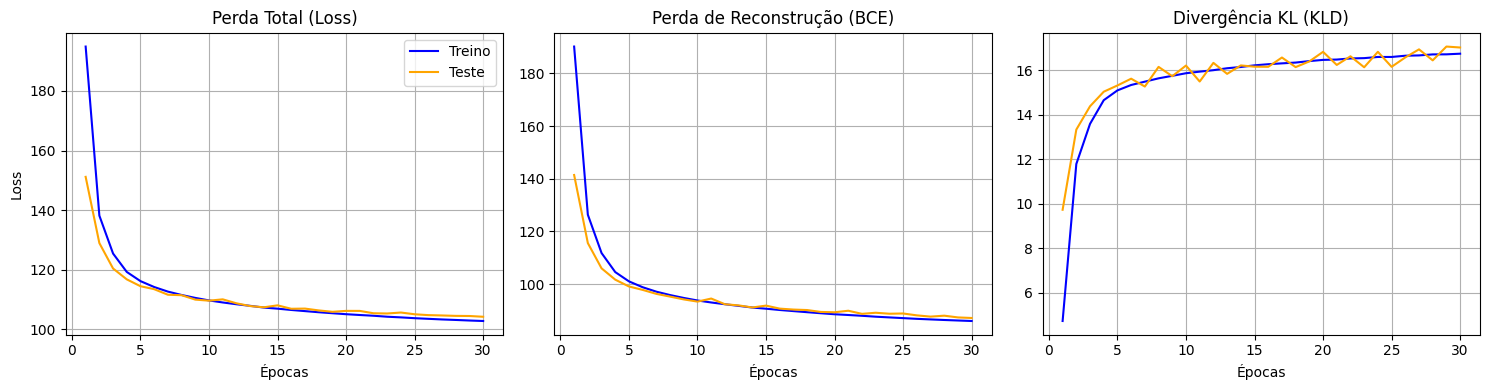

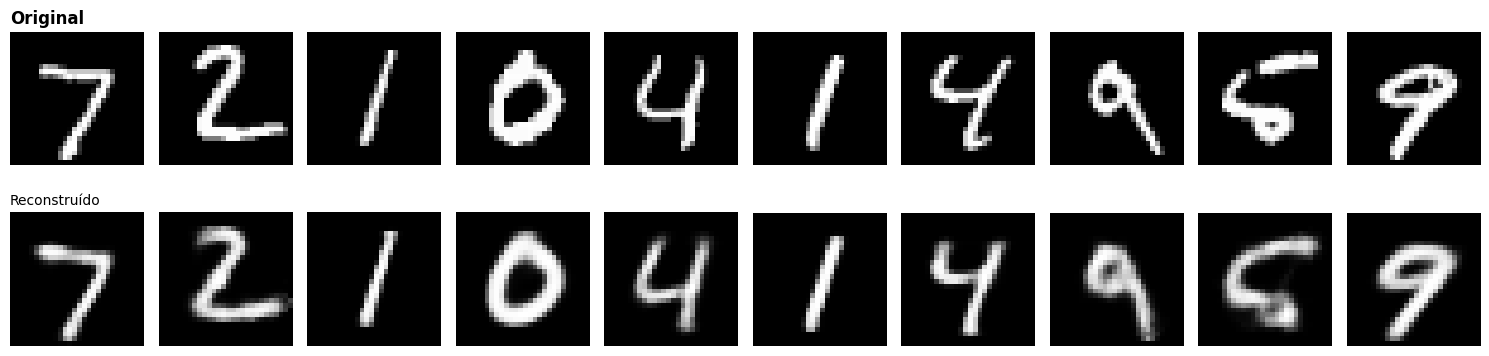

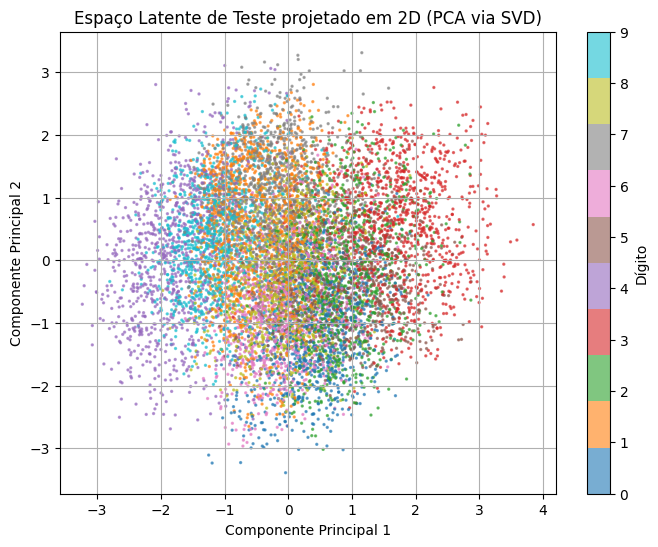

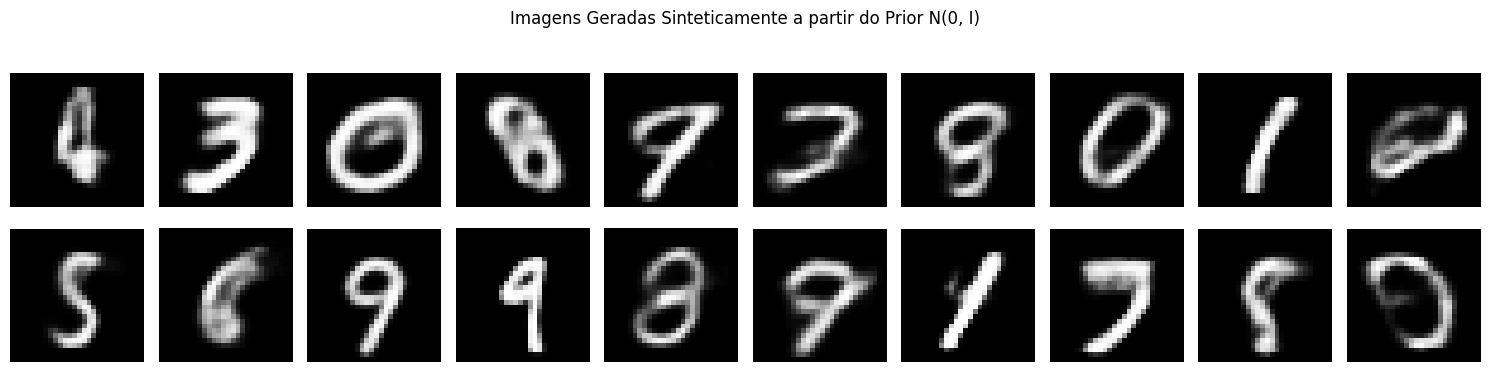

In [ ]:
# CURVAS DE TREINAMENTO 
model.eval()
plt.figure(figsize=(15, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

# Perda Total
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history["train_loss"], label="Treino", color="blue") 
plt.plot(epochs_range, history["test_loss"], label="Teste", color="orange")
plt.title("Perda Total (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Perda de Reconstrução
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history["train_recon"], label="Treino", color="blue") 
plt.plot(epochs_range, history["test_recon"], label="Teste", color="orange")
plt.title("Perda de Reconstrução (BCE)")
plt.xlabel("Épocas")
plt.grid(True)

# Divergência KL
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history["train_kl"], label="Treino", color="blue") 
plt.plot(epochs_range, history["test_kl"], label="Teste", color="orange")
plt.title("Divergência KL (KLD)")
plt.xlabel("Épocas")
plt.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "1.5a_curvas_treinamento.png", dpi=150)
plt.show()


# 10 RECONSTRUÇÕES LADO A LADO 
with torch.no_grad():
    x_real, y_real = next(iter(test_loader))
    x_real = x_real.to(device) 
    x_hat, _, _ = model(x_real)

x_real_np = x_real.cpu().numpy()
x_hat_np = x_hat.cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    # Linha superior: Imagens Originais
    axes[0, i].imshow(x_real_np[i, 0], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")
        
    # Linha inferior: Reconstruções correspondentes (Padronizado para indexação [i, 0])
    axes[1, i].imshow(x_hat_np[i, 0], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Reconstruído", loc="left", fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "1.5b_reconstrucoes.png", dpi=150)
plt.show()


#  ESPAÇO LATENTE EM 2D (PCA MANUAL VIA SVD) 
all_mus = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, _ = model.encoder(x)
        all_mus.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_mus = np.concatenate(all_mus, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

if LATENT_DIM > 2:
    mu_mean = np.mean(all_mus, axis=0)
    centered_mus = all_mus - mu_mean
    _, _, Vt = np.linalg.svd(centered_mus, full_matrices=False)
    # Projeção canônica usando os dois primeiros componentes principais
    latent_2d = np.dot(centered_mus, Vt[:2].T)
else:
    latent_2d = all_mus

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=all_labels, cmap="tab10", alpha=0.6, s=2)
plt.colorbar(scatter, label="Dígito")
plt.title("Espaço Latente de Teste projetado em 2D (PCA via SVD)" if LATENT_DIM > 2 else "Espaço Latente 2D")
plt.xlabel("Componente Principal 1" if LATENT_DIM > 2 else "Z1")
plt.ylabel("Componente Principal 2" if LATENT_DIM > 2 else "Z2")
plt.grid(True)
plt.savefig(output_dir / "1.5c_espaco_latente.png", dpi=150)
plt.show()


# 1.5d: AMOSTRAS DO PRIOR 
z_prior = torch.randn(20, LATENT_DIM).to(device)

with torch.no_grad():
    x_generated = model.decoder(z_prior)
    x_generated_np = x_generated.cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(20):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(x_generated_np[i, 0], cmap="gray")
    axes[row, col].axis("off")

plt.suptitle("Imagens Geradas Sinteticamente a partir do Prior N(0, I)", fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / "1.5d_amostras_prior.png", dpi=150)
plt.show()

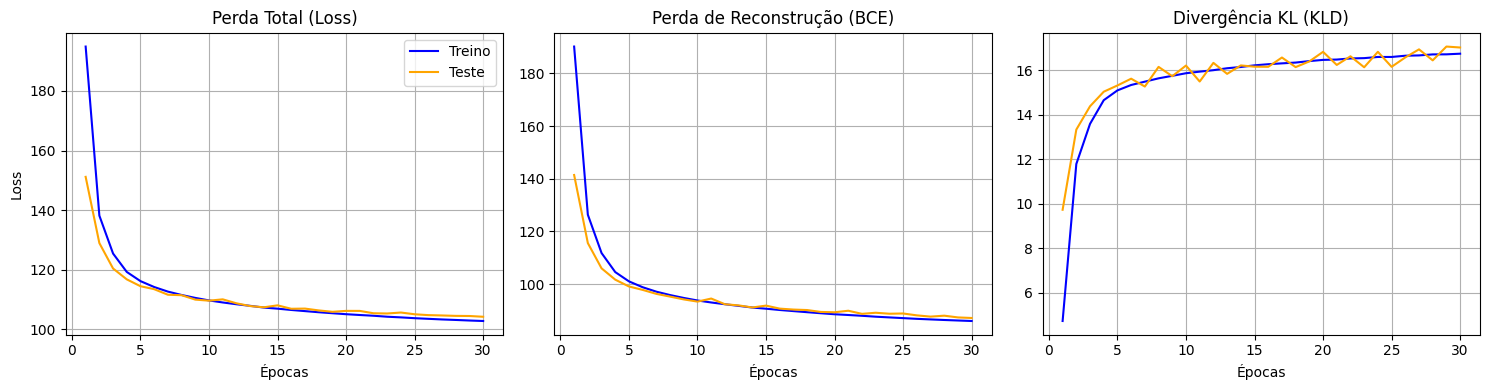

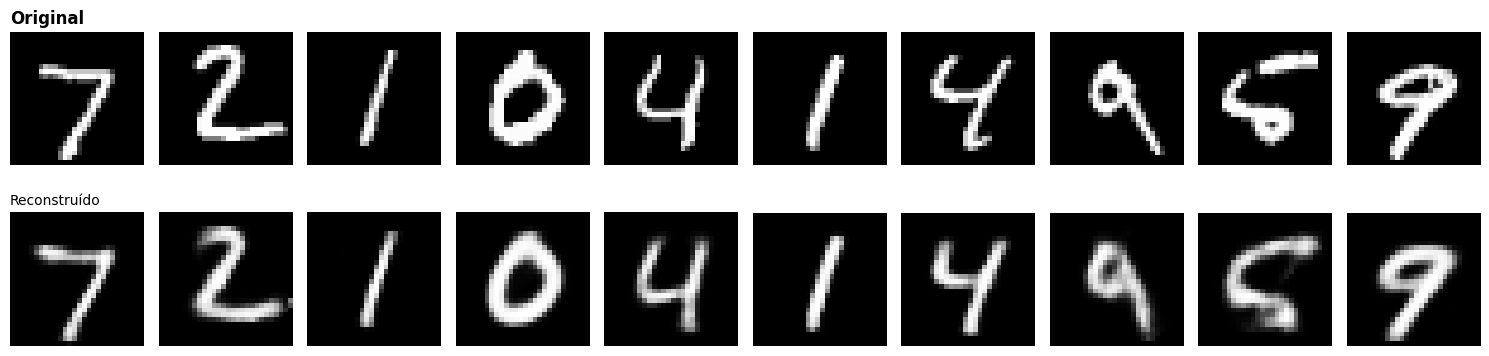

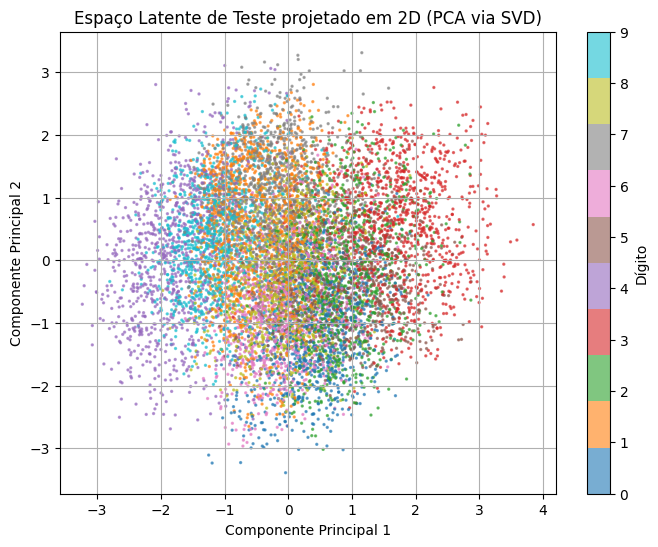

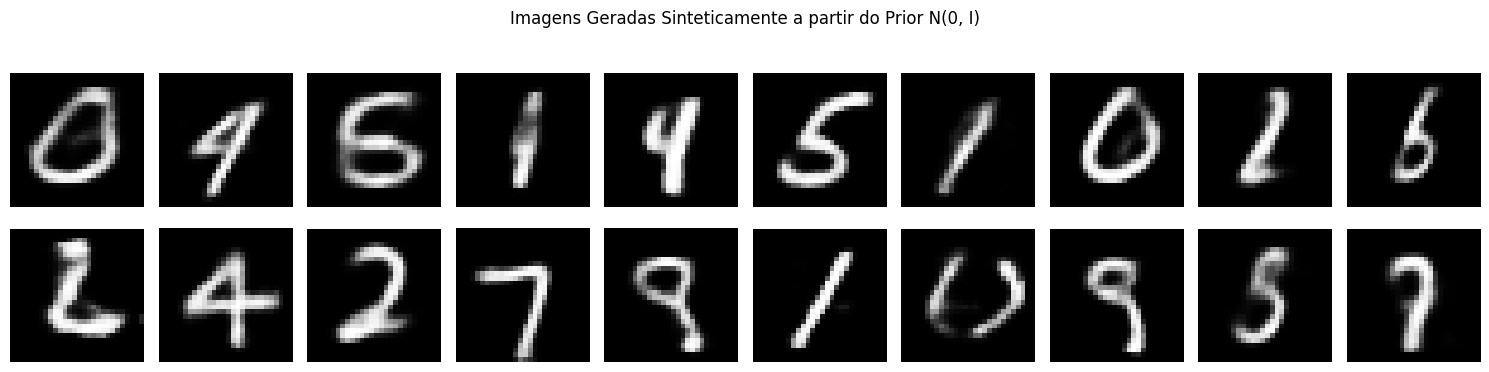

In [ ]:
# O modelo está no modo de avaliação e no dispositivo correto
model.eval()

plt.figure(figsize=(15, 4))

epochs_range = range(1, len(history["train_loss"]) + 1)

#  Perda Total
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history["train_loss"], label="Treino", color="blue")
plt.plot(epochs_range, history["test_loss"], label="Teste", color="orange")
plt.title("Perda Total (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

#  Perda de Reconstrução
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history["train_recon"], label="Treino", color="blue")
plt.plot(epochs_range, history["test_recon"], label="Teste", color="orange")
plt.title("Perda de Reconstrução (BCE)")
plt.xlabel("Épocas")
plt.grid(True)

#  Divergência KL
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history["train_kl"], label="Treino", color="blue")
plt.plot(epochs_range, history["test_kl"], label="Teste", color="orange")
plt.title("Divergência KL (KLD)")
plt.xlabel("Épocas")
plt.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "1.5a_curvas_treinamento.png", dpi=150)
plt.show()


# 1.5b: 10 RECONSTRUÇÕES LADO A LADO
model.eval()
with torch.no_grad():
    # Coletar o primeiro lote do loader de teste
    x_real, y_real = next(iter(test_loader))
    x_real = x_real.to(device) # Corrigido para minúsculo conforme o setup do seu notebook
    x_hat, _, _ = model(x_real)

# Conversão para arrays numpy para exibição gráfica
x_real_np = x_real.cpu().numpy()
x_hat_np = x_hat.cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    # Linha superior: Imagens Originais
    axes[0, i].imshow(x_real_np[i, 0], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")

        
    # Linha inferior: Reconstruções correspondentes
    axes[1, i].imshow(x_hat_np[i, 0], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Reconstruído", loc="left", fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "1.5b_reconstrucoes.png", dpi=150)
plt.show()


#  1.5c: ESPAÇO LATENTE EM 2D (PCA MANUAL VIA SVD)
all_mus = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, _ = model.encoder(x)
        all_mus.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

# Concatenar todos os batches do conjunto de teste
all_mus = np.concatenate(all_mus, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Aplicar redução de dimensionalidade se LATENT_DIM > 2
if LATENT_DIM > 2:
    # 1. Centralizar os dados (subtrair a média de cada coluna)
    mu_mean = np.mean(all_mus, axis=0)
    centered_mus = all_mus - mu_mean
    
    # Computar o SVD manual 
    _, _, Vt = np.linalg.svd(centered_mus, full_matrices=False)
    
    # Projetar os dados nas duas primeiras componentes principais (colunas de V, ou linhas de Vt)
    W2 = Vt[:2].T  # Matriz de projeção para as 2 primeiras componentes principais
    latent_2d = np.dot(centered_mus, W2)
    title_suffix = f"PCA via SVD (LATENT_DIM={LATENT_DIM})"
else:
    latent_2d = all_mus
    title_suffix = "Espaço Latente 2D"
# Plotar o scatter plot colorido por classe (dígito)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=all_labels, cmap="tab10", alpha=0.6, s=2)
plt.colorbar(scatter, label="Dígito")
plt.title(f"Espaço Latente de Teste projetado em 2D (PCA via SVD)" if LATENT_DIM > 2 else "Espaço Latente 2D")
plt.xlabel("Componente Principal 1" if LATENT_DIM > 2 else "Z1")
plt.ylabel("Componente Principal 2" if LATENT_DIM > 2 else "Z2")
plt.grid(True)
plt.savefig(output_dir / "1.5c_espaco_latente.png", dpi=150)
plt.show()


#TAREFA 1.5d: AMOSTRAS DO PRIOR (2X10 GRID) 
# Gerar 20 vetores latentes independentes seguindo N(0, I)
# Usar 8 (LATENT_DIM do modelo que foi treinado)
z_prior = torch.randn(20, 8).to(device)

with torch.no_grad():
    # Passar os vetores sintéticos apenas pelo Decoder
    x_generated = model.decoder(z_prior)

    x_generated_np = x_generated.cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(20):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(x_generated_np[i, 0], cmap="gray")
    axes[row, col].axis("off")

plt.suptitle("Imagens Geradas Sinteticamente a partir do Prior N(0, I)", fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / "1.5d_amostras_prior.png", dpi=150)
plt.show()

### Questão 1 — Análise do VAE base

**a)** Compare as curvas de treino e teste. O modelo apresenta underfitting, overfitting, ou está bem ajustado? Justifique com o gap treino/teste e a tendência das curvas.

* <span style="color:blue">**R:** O modelo apresenta-se bem ajustado não apresentando evidências de *underfitting* ou *overfitting*, as curvas de $\text{Perda total}$ e $\text{BCE}$ mostram um comportamento assintótico esperado, com decréscimo acelarado no inicio e depois estabilizando, simultâneamente a curva da divergência $\text{KL (KLD)}$ tem o mesmo comportamento porém em crescendo e estabilizando rapidamente. O $\text{Gap}$ apresentado entre o Treino/teste mostra esse fato bem sendo muito "pequena" (treino: 102.76 vs. teste: 104.18). E o fato de a curva de teste apresentar um movimento semelhante com certa precisão a trajetória de treino descarta o cenário de *overfitting* e A magnitude absoluta baixa do erro recon pós-convergência descarta também o *underfitting*.</span>

**b)** Compare reconstruções com amostras do prior. Em qual das duas o VAE produz imagens melhores? Por quê?

* <span style="color:blue">**R:** O $\text{VAE}$ produz imagens consideravelmentes melhores e mais nítidas no cenário de Reconstrução, do que no cenário de amostragem direta do $\text{prior}$. Visto que o Decoder ser condicionado por um vetor latente determinístico $z = \mu(x) + \sigma(x) \odot \epsilon$ que foi derivado de uma imagem real e passada para o Encoder, carregando assim componentes semânticas de alta relação ligadas à topologia do dígito específico. Por outro lado na amostragem prior é sorteado um vetor com que segue $\epsilon \sim \mathcal{N}(0, I)$ como pela divergência $\text{KL}$ temos uma restrição probabilística que comprime as distribuições, o espaço latente possui interseções, ocorrendo uma probabilidade não numa de selecionar coordenadas localizadas nas fronteiras de decisão entre as classes, O Decoder ao decodificar pode apresentar inconsistências por conta desses pontos de transição, apresentando menor nitidez, qualidade.

**c)** Na projeção 2D do espaço latente (direta se `LATENT_DIM=2`, via PCA caso contrário), as classes ficam separadas? Existem regiões vazias? Conecte a estrutura latente à qualidade das amostras geradas.

* <span style="color:blue">**R:** Temos uma formação de clusters semânticos bem definidos e geometricamente agrupados por cor, mas é possível observar uma transição contínua onde classes que compartilham semelhanças topológicas coincidem em regiões adjacentes e apresentam zonas de sobreposição em suas fronteiras de densidade. Não existem regiões vazias ou lacunas severas de esparsidade no espaço projetado. O preenchimento do espaço assume uma distribuição densa e concentrada em torno da origem, respeitando o confinamento geométrico imposto pela penalização da Divergência $\text{KL}$. A continuidade geométrica juntamente com a suavidade das fronteiras de transição estão diretamente conectadas à alta qualidade das amostras geradas. Como o espaço latente não foi fragmentado pelo Encoder, qualquer vetor aleatório z sorteado na vizinhança da distribuição Gaussiana cairá em uma região densamente mapeada pelo Decoder. Isso garante que o modelo interpole formas e gere representações numéricas visualmente coerentes e legíveis para qualquer coordenada latente explorada.

*Escreva sua resposta aqui (a, b, c).*

## Parte 2 — Marca d'água visível (warmup do auditor)

A versão mais simples do problema: o dono dos dados estampa um **patch branco fixo** num canto das imagens. Esta marca é trivialmente visível, mas serve como referência para entendermos o "limite superior" da detectabilidade.

### 2.1 Definir a marca e o dataset

A marca é um quadrado branco $4 \times 4$ no canto inferior direito (posição `[22:26, 22:26]`), valor $1.0$. Marcamos 20% das imagens de treino, selecionadas aleatoriamente com seed fixa.

**Tarefa 2.1.** Implemente:
- A função `apply_visible_watermark(img)`.
- A classe `VisibleWatermarkedMNIST` que envolve `train_ds` e marca aleatoriamente uma fração das imagens, mantendo `watermarked_indices` para análise posterior.

In [10]:
PATCH_ROW, PATCH_COL = 22, 22
PATCH_SIZE = 4
WM_FRACTION = 0.20


def apply_visible_watermark(img: torch.Tensor) -> torch.Tensor:
    # TODO: clone e estampe um quadrado branco PATCH_SIZE x PATCH_SIZE
    marca_img = img.clone()
    marca_img[:, PATCH_ROW:PATCH_ROW+PATCH_SIZE, PATCH_COL:PATCH_COL+PATCH_SIZE] = 1.0
    return marca_img


class VisibleWatermarkedMNIST(Dataset):
    def __init__(self, base_dataset, fraction=WM_FRACTION, seed=SEED):
        # TODO: amostrar índices a marcar (use np.random.default_rng(seed))
        self.base_dataset = base_dataset
        self.fraction = fraction
        rng = np.random.default_rng(seed)
        indices_array = rng.choice(
            len(base_dataset), 
            size=int(len(base_dataset) * fraction), 
            replace=False
        )

        self.watermarked_indices = set(indices_array)   

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        # TODO: retornar (img marcada se idx in indices else img, label)
        img, label = self.base_dataset[idx]
        if idx in self.watermarked_indices:
            img = apply_visible_watermark(img)
        return img, label


vis_ds = VisibleWatermarkedMNIST(train_ds)
print(f"Marcadas: {len(vis_ds.watermarked_indices):,} / {len(vis_ds):,}")

Marcadas: 12,000 / 60,000


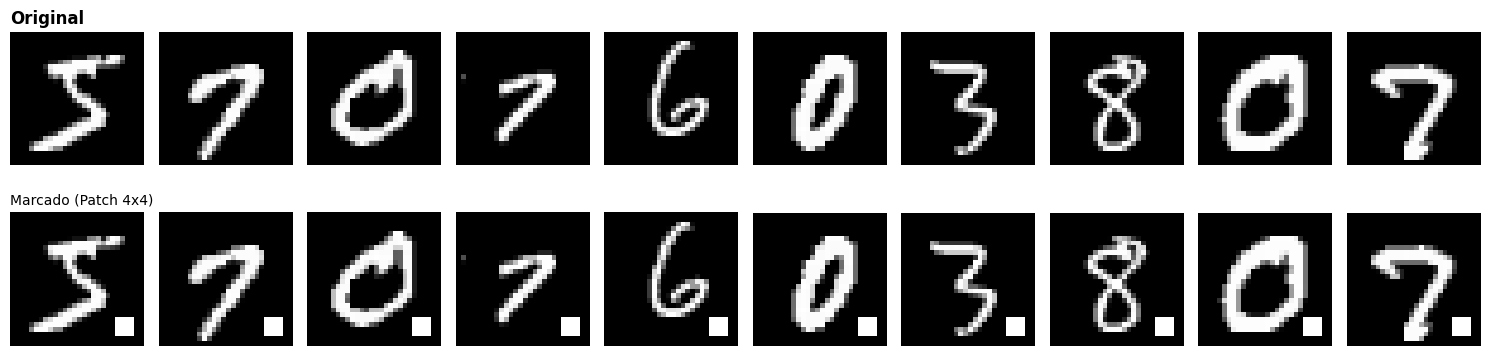

In [12]:
# 1. Extraindo os 10 primeiros índices que foram marcados de forma aleatória pelo construtor
indices_marcados = sorted(list(vis_ds.watermarked_indices))[:10]

# 2. Configurar a figura matplotlib com o grid exigido (2 linhas, 10 colunas)
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i, idx in enumerate(indices_marcados):
    # Extraindo a imagem original pura diretamente do dataset base
    img_original, _ = train_ds[idx]
    
    # Extraindo a imagem modificada do nosso dataset customizado
    img_marcada, _ = vis_ds[idx]
    
    # Conversão de tensores para arrays numpy para exibição espacial (C, H, W) -> (H, W)
    img_orig_np = img_original.squeeze().numpy()
    img_marc_np = img_marcada.squeeze().numpy()
    
    # Linha Superior (0): Amostras Originais
    axes[0, i].imshow(img_orig_np, cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")
        
    # Linha Inferior (1): Versões Marcadas 
    axes[1, i].imshow(img_marc_np, cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Marcado (Patch 4x4)", loc="left", fontsize=10)

plt.tight_layout()
# Salvar no diretório correto 
plt.savefig(output_dir / "2.1_amostras_marcadas_visivel.png", dpi=150)
plt.show()

### 2.2 Treinar o VAE marcado

Treine um novo VAE (`vae_vis`) com **a mesma arquitetura** do `model` (mesma `LATENT_DIM`) mas usando `vis_ds` como dataset de treino. Use 30 épocas, Adam lr=1e-3.

**Dica.** Modularize: escreva uma função `train_vae(loader, latent_dim, epochs, label)` que cria, treina e retorna um novo VAE. Vamos reutilizá-la várias vezes nas próximas partes.

In [13]:
def train_vae(loader, latent_dim, epochs, label, lr=1e-3):
    # TODO: criar VAE(latent_dim), Adam, loop de épocas
    # TODO: print resumo a cada N épocas
    model_instanciado = VAE(latent_dim).to(device)
    optimizer_instanciado = torch.optim.Adam(model_instanciado.parameters(), lr=lr)

    print(f"Treinando VAE {label.upper()} com LATENT_DIM={latent_dim} por {epochs} épocas...")

    for epoch in range(1, epochs + 1):
        model_instanciado.train()
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0  
        
        for x, _ in loader:
            x = x.to(device)
            optimizer_instanciado.zero_grad()
            x_hat, mu, log_var = model_instanciado(x)
            loss, recon_loss, kl_loss = vae_loss(x, x_hat, mu, log_var)
            loss.backward()
            optimizer_instanciado.step()
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()


        avg_loss = total_loss / len(loader.dataset)
        avg_recon = total_recon / len(loader.dataset)
        avg_kl = total_kl / len(loader.dataset)

        #if epoch % 5 == 0 or epoch == 1:
        print(f"Época {epoch:3d}/{epochs} | Loss: {avg_loss:.2f} | Reconstrução: {avg_recon:.2f} | KL: {avg_kl:.2f}")
            
    print(f"Treinamento [{label.upper()}] Concluído com sucesso.")
    return model_instanciado


vis_loader = DataLoader(vis_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
vae_vis = train_vae(vis_loader, LATENT_DIM, epochs=30, label="vis")
torch.save(vae_vis.state_dict(), output_dir / "vae_visible.pt")
print("Modelo VAE treinado com dataset visivelmente marcado e salvo com sucesso.")

Treinando VAE VIS com LATENT_DIM=8 por 30 épocas...
Época   1/30 | Loss: 203.36 | Reconstrução: 198.82 | KL: 4.55
Época   2/30 | Loss: 142.84 | Reconstrução: 130.99 | KL: 11.84
Época   3/30 | Loss: 128.72 | Reconstrução: 114.93 | KL: 13.79
Época   4/30 | Loss: 122.74 | Reconstrução: 107.90 | KL: 14.84
Época   5/30 | Loss: 119.44 | Reconstrução: 104.19 | KL: 15.25
Época   6/30 | Loss: 117.33 | Reconstrução: 101.82 | KL: 15.51
Época   7/30 | Loss: 115.65 | Reconstrução: 99.98 | KL: 15.67
Época   8/30 | Loss: 114.44 | Reconstrução: 98.58 | KL: 15.86
Época   9/30 | Loss: 113.34 | Reconstrução: 97.38 | KL: 15.96
Época  10/30 | Loss: 112.54 | Reconstrução: 96.47 | KL: 16.07
Época  11/30 | Loss: 111.76 | Reconstrução: 95.61 | KL: 16.15
Época  12/30 | Loss: 111.04 | Reconstrução: 94.83 | KL: 16.21
Época  13/30 | Loss: 110.49 | Reconstrução: 94.19 | KL: 16.30
Época  14/30 | Loss: 109.97 | Reconstrução: 93.57 | KL: 16.39
Época  15/30 | Loss: 109.48 | Reconstrução: 93.05 | KL: 16.43
Época  16/30 

### 2.3 Auditoria visual

Use **o mesmo $z$** para gerar amostras de `model` (limpo) e `vae_vis` (com marca). Mostre lado a lado.

**Tarefa 2.3.** Plote 20 amostras de cada modelo (mesmo $z$), em duas linhas — limpo em cima, marcado embaixo.

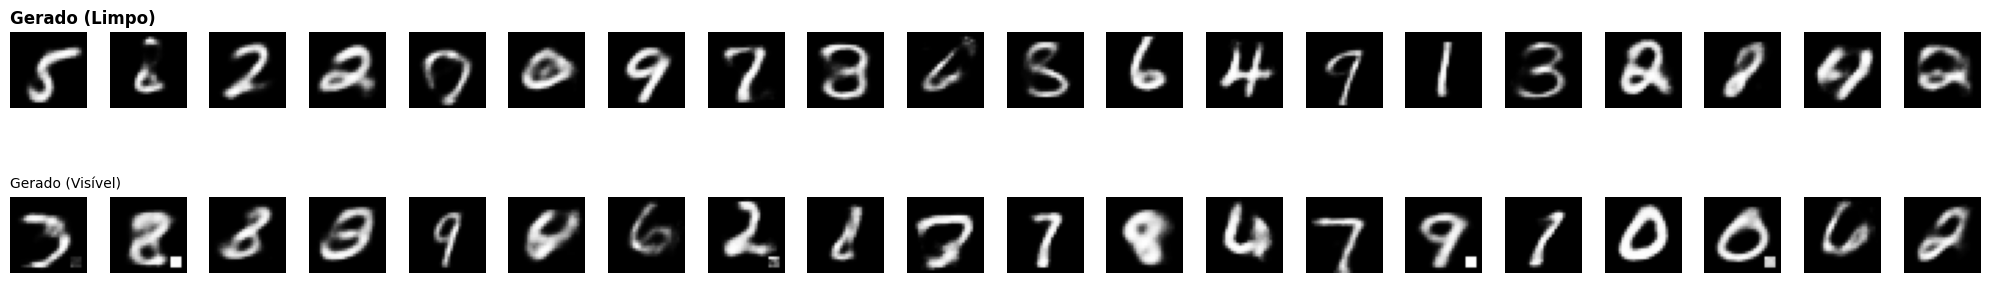

In [18]:
N = 20

model.eval()
vae_vis.eval()

with torch.no_grad():
    # Amostrar o mesmo z para ambos os modelos
    z_comum = torch.randn(N, LATENT_DIM).to(device)
    # Decodificar usando o modelo original (limpo)
    x_gen_limpo = model.decoder(z_comum)
    # Decodificar usando o modelo treinado com dataset visivelmente marcado
    x_gen_vis = vae_vis.decoder(z_comum)

x_gen_limpo_np = x_gen_limpo.cpu().numpy()
x_gen_vis_np = x_gen_vis.cpu().numpy()

fig, axes = plt.subplots(2, N, figsize=(20, 4))
for i in range(N):
    # Linha superior: Imagens geradas pelo modelo limpo
    axes[0, i].imshow(x_gen_limpo_np[i, 0], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Gerado (Limpo)", loc="left", fontsize=12, fontweight="bold")
        
    # Linha inferior: Imagens geradas pelo modelo visivelmente marcado
    axes[1, i].imshow(x_gen_vis_np[i, 0], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Gerado (Visível)", loc="left", fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "2.3_comparacao_geracao.png", dpi=150)
plt.show()        

# TODO: amostre o mesmo z, decodifique nos 2 modelos, plote lado a lado
# raise NotImplementedError

### 2.4 Auditoria estatística

Quantifique o sinal calculando o **valor médio de pixel** dentro da região do patch:

$$\text{patch\_mean}(x) = \frac{1}{|P|} \sum_{(i,j) \in P} x_{ij}, \quad P = \{(i,j) : 22 \le i, j < 26\}$$

**Tarefa 2.4.** Implemente `patch_mean(imgs)` (tensor `(N, 1, 28, 28)` → tensor `(N,)`). Compute essa métrica para 4 grupos e plote um bar chart comparativo com erro padrão:
1. Imagens limpas do teste (primeiras 1000).
2. Imagens marcadas do treino (primeiros 1000 índices marcados).
3. 1000 amostras do `model` (VAE limpo).
4. 1000 amostras do `vae_vis`.

Métricas calculadas com sucesso.
Média Gerado VAE Marcado: 0.2242 | Média Gerado VAE Limpo: 0.0026
Lift Estatístico Obtido: 85.54x


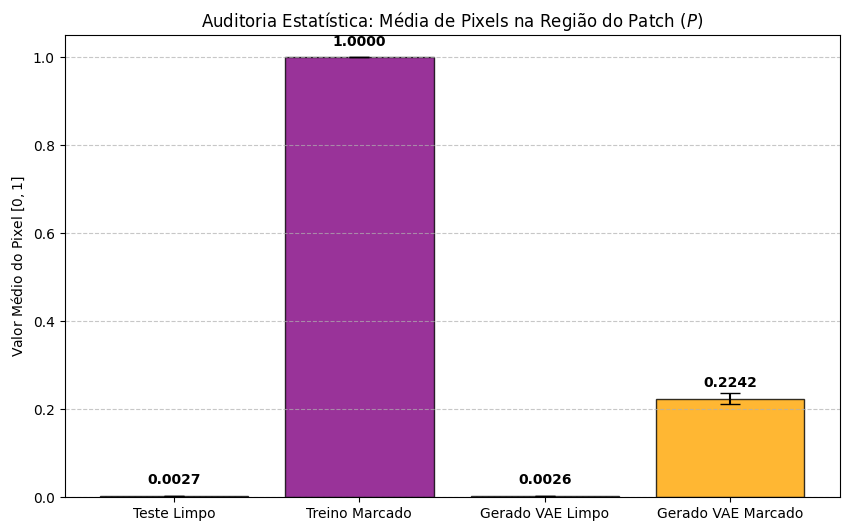

In [19]:
def patch_mean(imgs: torch.Tensor) -> torch.Tensor:
    # imgs tem o formato (N, 1, 28, 28)
    # Seleciona a janela espacial [22:26, 22:26] e extrai a média ao longo das dimensões de canal e espaciais (dim=1, 2, 3)
    return imgs[:, :, PATCH_ROW:PATCH_ROW+PATCH_SIZE, PATCH_COL:PATCH_COL+PATCH_SIZE].mean(dim=(1, 2, 3))

# PREPARAÇÃO DOS DADOS PARA AUDITORIA QUANTITATIVA (N = 1000) 
N_AUDIT = 1000
model.eval()
vae_vis.eval()

# Grupo 1: Imagens limpas do dataset de teste (primeiras 1000)
# Coletando via sub-fatiamento do DataLoader ou indexação direta
x_teste_limpo = torch.stack([test_ds[i][0] for i in range(N_AUDIT)]).to(device)

# Grupo 2: Imagens marcadas do dataset de treino (primeiros 1000 índices marcados)
indices_treino_marcados = sorted(list(vis_ds.watermarked_indices))[:N_AUDIT]
x_treino_marcado = torch.stack([vis_ds[idx][0] for idx in indices_treino_marcados]).to(device)

# Gerarando vetores latentes independentes para as amostras sintéticas
with torch.no_grad():
    z_audit = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    # Grupo 3: 1000 amostras geradas pelo VAE limpo
    x_gen_limpo = model.decoder(z_audit)
    # Grupo 4: 1000 amostras geradas pelo VAE marcado
    x_gen_marcado = vae_vis.decoder(z_audit)

# CÁLCULO DAS MÉTRICAS E ERRO PADRÃO
grupos = {
    "Teste Limpo": x_teste_limpo,
    "Treino Marcado": x_treino_marcado,
    "Gerado VAE Limpo": x_gen_limpo,
    "Gerado VAE Marcado": x_gen_marcado
}

means = []
stds = []

for nome, tensores in grupos.items():
    valores = patch_mean(tensores).cpu().numpy()
    means.append(np.mean(valores))
    # Erro padrão da média = desvio padrão / sqrt(N)
    stds.append(np.std(valores) / np.sqrt(N_AUDIT))

# PLOTAGEM DO GRÁFICO DE BARRAS EXIGIDO
plt.figure(figsize=(10, 6))
cores = ["gray", "purple", "lightgray", "orange"]
bars = plt.bar(grupos.keys(), means, yerr=stds, capsize=7, color=cores, edgecolor="black", alpha=0.8)

# Anotar os valores numéricos no topo de cada barra para servir de evidência na Q2
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.4f}", ha="center", va="bottom", fontweight="bold")

plt.title("Auditoria Estatística: Média de Pixels na Região do Patch ($P$)")
plt.ylabel("Valor Médio do Pixel $[0, 1]$")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Calcular o Lift (razão entre Gerado Marcado e Gerado Limpo)
lift = means[3] / (means[2] if means[2] > 0 else 1e-6)
print(f"Métricas calculadas com sucesso.")
print(f"Média Gerado VAE Marcado: {means[3]:.4f} | Média Gerado VAE Limpo: {means[2]:.4f}")
print(f"Lift Estatístico Obtido: {lift:.2f}x")

plt.savefig(output_dir / "2.4_auditoria_estatistica_barras.png", dpi=150)
plt.show()

### Questão 2 — Auditoria da marca visível

**a)** Nas amostras lado a lado (Tarefa 2.3), o patch aparece nas amostras do VAE marcado? Em quantas das 20 é visualmente óbvio?

- <span style="color:blue">**R:** Sim, o patch esteve presente de forma evidente nas amostras geradas pelo VAE treinado com o dataset marcado (vae_vis). Inspecionando o grid de 20 amostras a marca d'água é visualmente óbvia em 5 das 20 imagens geradas (nas amostras de índice de coluna: 1, 2, 8, 15 e 18).Justificativa do fenômeno: Nas outras 15 amostras, o patch quadrado não é discernível a olho nu. Isso ocorre porque o modelo foi exposto à marca em apenas uma fração minoritária dos dados de treino (20%). Consequentemente, o Decoder projeta o sinal majoritário do fundo preto (80% de probabilidade nos dados de treino) na maior parte do espaço latente.</span>

**b)** Compare `patch_mean` das amostras geradas pelos dois VAEs. Reporte os valores e o lift. O que esse número significa fisicamente?

- <span style="color:blue">`patch_mean` do VAE Limpo: 0.0026</span>
-  <span style="color:blue">`patch_mean` do VAE Marcado: 0.2242</span>
- <span style="color:blue">* $\text{Lift Estatístico Obtido:}$: 85,54x </span>
- <span style="color:blue"> O valor de 0,2242 representa a intensidade luminosa média esperada para a submatriz espacial 4×4 ao longo de um lote assintótico de gerações. Esse valor correlaciona-se diretamente com a proporção de dados marcados inseridos no treinamento (20%). A elevação, *$\text{Lift}$  drástica de 85,54 vezes em relação ao modelo de referência atua como uma assinatura probabilística de contaminação. Ela prova que a distribuição geradora do modelo suspeito foi severamente deslocada para reproduzir energia eletromagnética (pixels brancos) em uma região geométrica onde a distribuição natural dos dados (MNIST Limpo ≈0.0027) dita haver ausência total de informação (fundo preto).</span>

**c)** Proponha um ataque concreto que o dono do modelo poderia aplicar para destruir este sinal sem prejudicar muito a qualidade visual.

- <span style="color:blue">**R:** A grande questão é que o sinal se localiza na mesma região nas imagens geradas, isso pode ser atacado fazendo um isolamento de pós-processamento nessa região capaz de inibir tais capacteísticas, apagar ou forçar essa região centralizada para preto absoluto destruirá completamente o Lift estatístico obtido pelo auditor sem alterar a topologia ou a legibilidade da estrutura central do dígito.</span>

*Escreva suas respostas aqui (a, b, c).*

## Parte 3 — Marca d'água imperceptível (spread-spectrum)

A marca visível é trivial de remover. Agora projetamos uma marca **invisível ao olho** mas **detectável estatisticamente** — a base dos sistemas de watermarking spread-spectrum.

### 3.1 O padrão secreto

A marca usa uma textura pseudo-aleatória $w \in \mathbb{R}^{28 \times 28}$ conhecida apenas pelo auditor (o dono dos dados). A imagem marcada é:

$$x' = \text{clamp}(x + \varepsilon \cdot w,\, 0, 1)$$

O padrão é gerado a partir de `OWNER_SEED` — apenas o dono dos dados conhece essa chave e pode regenerar $w$ para auditar. O treinador do modelo não precisa conhecê-la.

**Tarefa 3.1.** Execute a célula abaixo — ela já está pronta. O código gera `wm_pattern` a partir de `OWNER_SEED` (usando `torch.Generator` para não perturbar a semente global), **subtrai a média** e normaliza pelo valor absoluto máximo (cada elemento fica em $[-1, 1]$). A visualização usa o mapa de cor `RdBu`. Confirme que a média impressa é $\approx 0$ e que $\max|w| = 1$.

wm_pattern - média: 1.22e-09  max|w|: 1.00


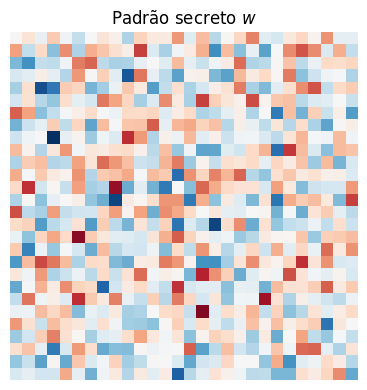

In [20]:
EPSILON        = 0.10
WM_FRACTION_SS = 0.20

# Gerado com OWNER_SEED (isolado do RNG global)
_owner_gen = torch.Generator().manual_seed(OWNER_SEED)
wm_pattern = torch.randn(1, 28, 28, generator=_owner_gen)
wm_pattern = wm_pattern - wm_pattern.mean()
wm_pattern = wm_pattern / wm_pattern.abs().max()

print(f"wm_pattern - média: {wm_pattern.mean().item():.2e}  max|w|: {wm_pattern.abs().max().item():.2f}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(wm_pattern.squeeze(), cmap="RdBu", vmin=-1, vmax=1)
ax.set_title("Padrão secreto $w$"); ax.axis("off")
plt.tight_layout(); plt.savefig(output_dir / "ss_pattern.png", dpi=120); plt.show()

### 3.2 Dataset com marca aditiva

**Tarefa 3.2.** Implemente `SpreadSpectrumMNIST` no mesmo padrão de `VisibleWatermarkedMNIST`, mas aplicando `x' = clamp(x + EPSILON * wm_pattern, 0, 1)`. Visualize um exemplo: original, marcado, e a diferença (amplificada para ser visível).

Marcadas: 12,000 / 60,000


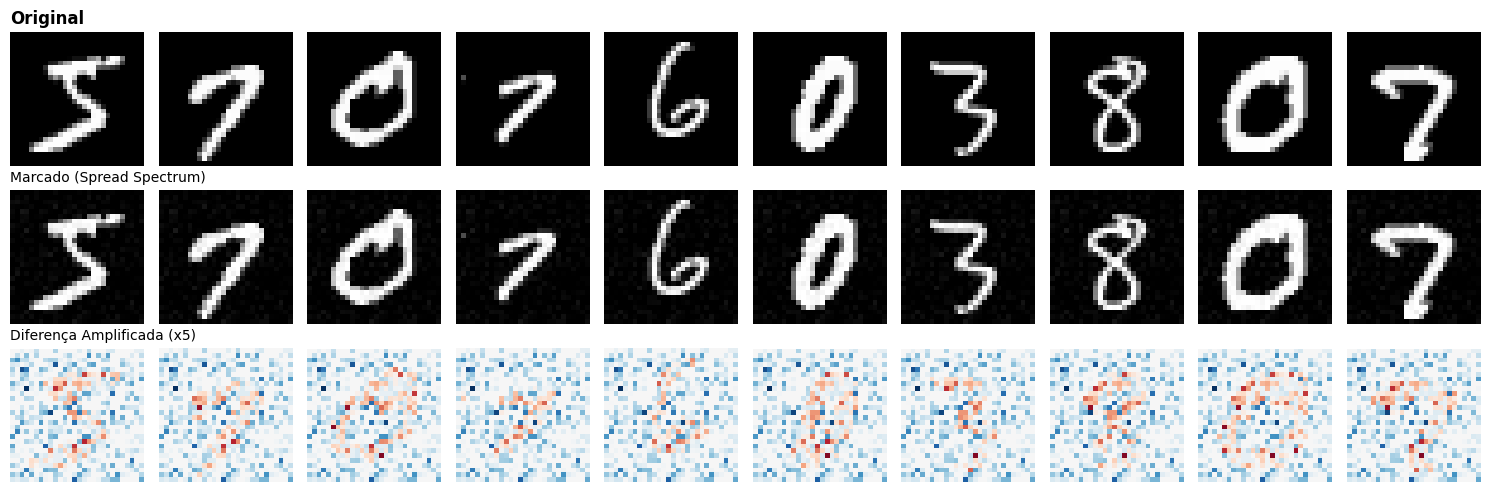

In [21]:
def apply_ss_watermark(img):
    # TODO
    imagem_mod = img.clone()
    imagem_ruido = imagem_mod + EPSILON * wm_pattern
    imagem_clamed = torch.clamp(imagem_ruido, 0.0, 1.0)
    return imagem_clamed
    


class SpreadSpectrumMNIST(Dataset):
    # TODO
    def __init__(self, base_dataset, fraction=WM_FRACTION_SS, seed=SEED):
        self.base_dataset = base_dataset
        self.fraction = fraction
        rng = np.random.default_rng(seed)
        indices_array = rng.choice(
            len(base_dataset), 
            size=int(len(base_dataset) * fraction), 
            replace=False
        )
        self.wm_indices = set(indices_array)

    def __len__(self):        
        return len(self.base_dataset)    
    
    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        if idx in self.wm_indices:
            img = apply_ss_watermark(img)
        return img, label
    


ss_ds = SpreadSpectrumMNIST(train_ds, fraction=WM_FRACTION_SS)
print(f"Marcadas: {len(ss_ds.wm_indices):,} / {len(ss_ds):,}")

# TODO: visualizar original vs marcado vs (marcado-original)*5
indices_ss = sorted(list(ss_ds.wm_indices))[:10]
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for i, idx in enumerate(indices_ss):    
    img_original, _ = train_ds[idx]
    img_marcada, _ = ss_ds[idx]
    img_diferenca = (img_marcada - img_original) * 5.0
    
    axes[0, i].imshow(img_original.squeeze(), cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")
        
    axes[1, i].imshow(img_marcada.squeeze(), cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Marcado (Spread Spectrum)", loc="left", fontsize=10)
        
    axes[2, i].imshow(img_diferenca.squeeze(), cmap="RdBu", vmin=-EPSILON*5, vmax=EPSILON*5)
    axes[2, i].axis("off")
    if i == 0:
        axes[2, i].set_title("Diferença Amplificada (x5)", loc="left", fontsize=10)
plt.tight_layout()
plt.savefig(output_dir / "3.2_visualizacao_spread_spectrum.png", dpi=150)
plt.show()


### 3.3 Treinar VAE com a marca imperceptível

Use `train_vae` (definida na Parte 2) para treinar `vae_ss` em `ss_ds`. Mesma arquitetura, 30 épocas.

In [22]:
ss_loader = DataLoader(ss_ds, 
                       batch_size=BATCH_SIZE, 
                       shuffle=True, 
                       num_workers=0, 
                       pin_memory=True)

# TODO: treine vae_ss e salve
vae_ss = train_vae(ss_loader, 
                   LATENT_DIM, 
                   epochs=30, 
                   label="spread_spectrum")
torch.save(vae_ss.state_dict(), output_dir / "vae_spread_spectrum.pt")
print("Modelo VAE treinado com dataset de marcação por Spread Spectrum e salvo com sucesso.")   


Treinando VAE SPREAD_SPECTRUM com LATENT_DIM=8 por 30 épocas...
Época   1/30 | Loss: 203.94 | Reconstrução: 199.38 | KL: 4.56
Época   2/30 | Loss: 147.57 | Reconstrução: 135.83 | KL: 11.74
Época   3/30 | Loss: 133.65 | Reconstrução: 119.92 | KL: 13.73
Época   4/30 | Loss: 127.90 | Reconstrução: 113.28 | KL: 14.61
Época   5/30 | Loss: 124.87 | Reconstrução: 109.88 | KL: 14.99
Época   6/30 | Loss: 122.92 | Reconstrução: 107.69 | KL: 15.23
Época   7/30 | Loss: 121.50 | Reconstrução: 106.10 | KL: 15.40
Época   8/30 | Loss: 120.38 | Reconstrução: 104.84 | KL: 15.54
Época   9/30 | Loss: 119.50 | Reconstrução: 103.85 | KL: 15.65
Época  10/30 | Loss: 118.67 | Reconstrução: 102.92 | KL: 15.74
Época  11/30 | Loss: 117.95 | Reconstrução: 102.13 | KL: 15.82
Época  12/30 | Loss: 117.41 | Reconstrução: 101.51 | KL: 15.90
Época  13/30 | Loss: 116.88 | Reconstrução: 100.92 | KL: 15.96
Época  14/30 | Loss: 116.35 | Reconstrução: 100.31 | KL: 16.04
Época  15/30 | Loss: 115.90 | Reconstrução: 99.82 | KL:

### 3.4 Detector ingênuo de correlação (e por que ele tem um problema)

O detector natural é a **correlação** entre uma imagem gerada e o padrão secreto:

$$\text{score}(x) = \langle x,\, w \rangle = \sum_{i,j} x_{ij} \, w_{ij}$$

**Tarefa 3.4a.** Implemente `corr_score(imgs, pattern)` e calcule os scores para 2000 amostras do `model` (limpo) e 2000 do `vae_ss` (marcado). Plote ambos como histogramas sobrepostos.

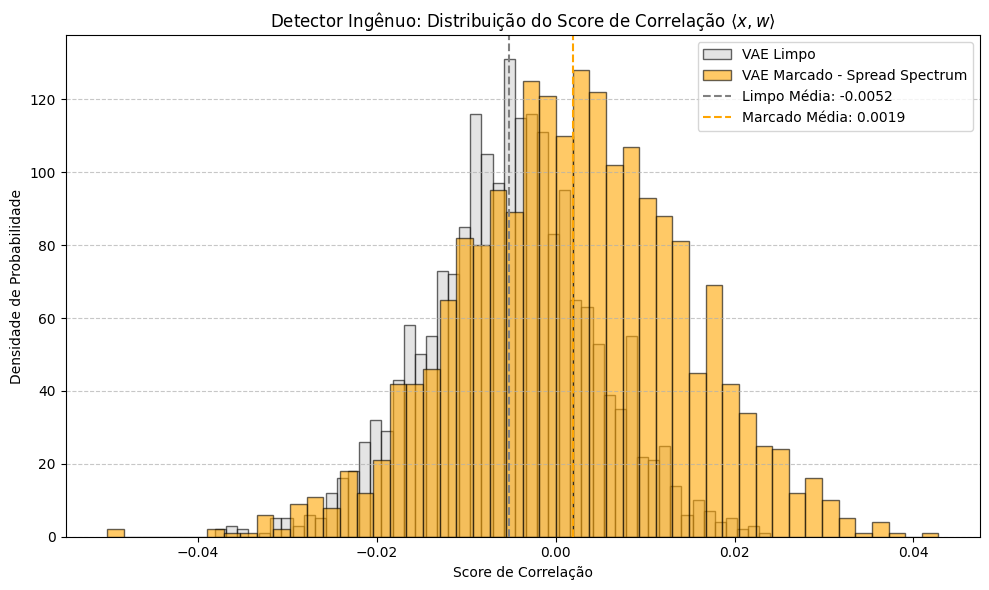

In [ ]:
def corr_score(imgs, pattern):
    # TODO: produto interno por imagem
    return (imgs * pattern).sum(dim=(1, 2, 3)) / pattern.abs().sum()
    
N_AUDIT = 2000
model.eval()
vae_ss.eval()
# TODO: gerar amostras com o mesmo z, computar scores, plotar histogramas
with torch.no_grad():
    z_audit = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    x_gen_limpo = model.decoder(z_audit)
    x_gen_ss = vae_ss.decoder(z_audit)

pattern = wm_pattern.to(device)
scores_limpo = corr_score(x_gen_limpo, pattern).cpu().numpy()
scores_marcados = corr_score(x_gen_ss, pattern).cpu().numpy()

plt.figure(figsize=(10, 6))
plt.hist(scores_limpo, bins=50, alpha=0.6, label="VAE Limpo", color="lightgray", edgecolor="black")
plt.hist(scores_marcados, bins=50, alpha=0.6, label="VAE Marcado - Spread Spectrum", color="orange", edgecolor="black")

plt.axvline(scores_limpo.mean(), color="gray", linestyle="dashed", label=f"Limpo Média: {scores_limpo.mean():.4f}", linewidth=1.5)
plt.axvline(scores_marcados.mean(), color="orange", linestyle="dashed", label=f"Marcado Média: {scores_marcados.mean():.4f}", linewidth=1.5)    

plt.title("Detector Ingênuo: Distribuição do Score de Correlação $\\langle x, w \\rangle$")
plt.xlabel("Score de Correlação")
plt.ylabel("Densidade de Probabilidade")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(output_dir / "3.4_histogramas_scores.png", dpi=150)
plt.show()


### 3.5 Diagnóstico: por que o VAE limpo não está centrado em zero?

Você provavelmente observou que o histograma do **VAE limpo** não está centrado em $0$. Isso parece contraditório: o modelo nunca viu $w$, então a correlação não deveria ser ruído puro?

**Tarefa 3.5.** Explique matematicamente por que $\mathbb{E}[\langle x_{\text{clean}}, w \rangle] \ne 0$ em geral. Calcule numericamente o valor que causa esse desvio e mostre que ele coincide com a média empírica do histograma.

O detector ingênuo calcula a correlação $\langle x, w \rangle$. Se for calculado o valor esperado dessa pontuação para uma imagem perfeitamente limpa $x_{\text{clean}}$, é usado a propriedade da linearidade da esperança, com isso temos: $$\mathbb{E}[\langle x_{\text{clean}}, w \rangle]=\mathbb{E}[\sum_{ij}{(x_{\text{clean}}})_{ij}w_{ij}]$$

Como o padrão secreto w é uma matriz constante e fixa para o auditor, podemos tirá-lo da esperança:
$$\mathbb{E}[\langle x_{\text{clean}}, w \rangle]=\sum_{ij}{\mathbb{E}[{(x_{\text{clean}}})_{ij}]w_{ij}}=\langle \mathbb{E}[{x_{\text{clean}}}],w \rangle = \langle \mu_{\text{mnist}},w \rangle $$

Embora o padrão $w$ tenha média zero $\sum_{}{w_{ij}}=0$ a imagem média do MNIST ($\mu_{\text{mnist}}$), **não é uniforme**. Ela é uma elipse brilhante concentrada no centro da grade 28×28

In [24]:
# TODO: compute a imagem média do MNIST limpo (mu_mnist) e seu produto interno com wm_pattern
# Compare com a média do histograma do VAE limpo da seção anterior — devem ser parecidos.
# raise NotImplementedError


with torch.no_grad():
    todas_imagens = train_ds.data.float() / 255.0
    mu_mnist= todas_imagens.mean(dim=0).unsqueeze(0).to(device)
    wm_device = wm_pattern.to(device)
    offset_teorico = (mu_mnist * wm_device).sum().item()

print("Diagnótico do Detector Ingênuo:")    
print(f"Offset Teórico: {offset_teorico:.4f}")
print(f"Score Médio do VAE Limpo: {scores_limpo.mean():.4f}")
print(f"Score Médio do VAE Marcado: {scores_marcados.mean():.4f}")

diferenca = abs(offset_teorico - scores_marcados.mean())
print(f"Diferença Absoluta entre Offset Teórico e Score Médio do VAE Marcado: {diferenca:.4f}")

Diagnótico do Detector Ingênuo:
Offset Teórico: -1.0688
Score Médio do VAE Limpo: -0.0052
Score Médio do VAE Marcado: 0.0019
Diferença Absoluta entre Offset Teórico e Score Médio do VAE Marcado: 1.0707


### 3.6 Detector centralizado

Para o detector ser interpretável (histograma centrado em zero sob $H_0$), subtraia o offset $\langle \mu_{\text{MNIST}}, w \rangle$ centralizando as imagens antes de calcular a correlação:

$$\text{corr\_centered}(x) = \langle x - \mu_{\text{MNIST}},\, w \rangle$$

**Tarefa 3.6.** Implemente `corr_score_centered(imgs, pattern, mean_img)` e refaça o histograma. O histograma do VAE limpo deve agora aparecer próximo de zero.

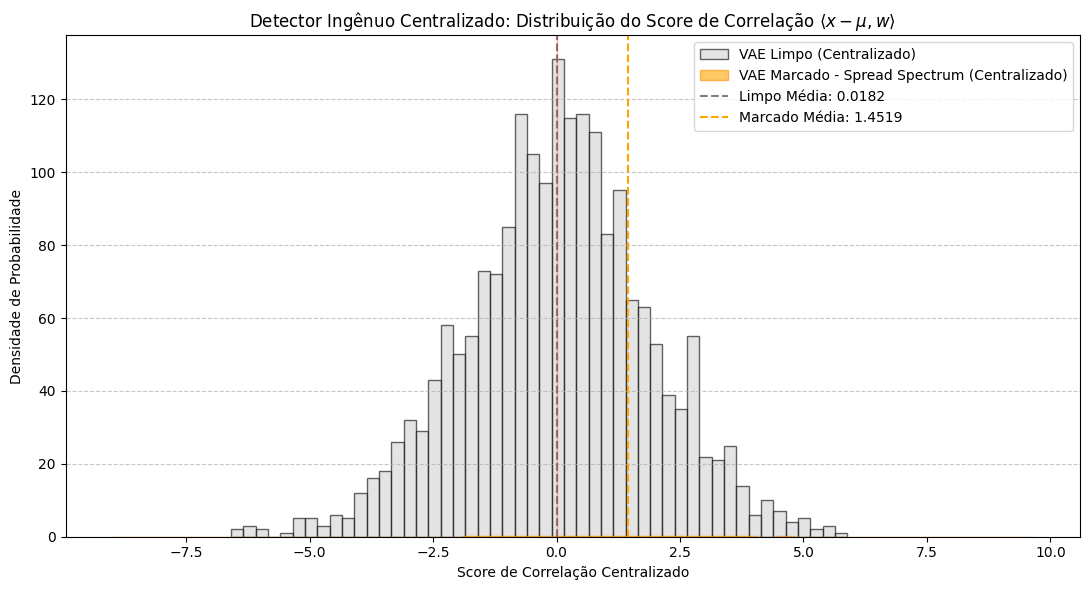

In [25]:
def corr_score_centered(imgs, pattern, mean_img):
    # TODO: <x - mean_img, pattern>
    imagem_centralizada = imgs - mean_img
    return (imagem_centralizada * pattern).sum(dim=(1, 2, 3))

model.eval()
vae_ss.eval()

with torch.no_grad():
    pattern = wm_pattern.to(device)
    acores_limpo_centered = corr_score_centered(x_gen_limpo, pattern, mu_mnist).cpu().numpy()
    acores_marcados_centered = corr_score_centered(x_gen_ss, pattern, mu_mnist).cpu().numpy()

plt.figure(figsize=(11, 6))
plt.hist(acores_limpo_centered, bins=50, alpha=0.6, label="VAE Limpo (Centralizado)", color="lightgray", edgecolor="black")
plt.hist(acores_marcados_centered, bins=50, alpha=0.6, label="VAE Marcado - Spread Spectrum (Centralizado)", color="orange", edgecolor="darkorange", density=True)

plt.axvline(acores_limpo_centered.mean(), color="gray", linestyle="dashed", label=f"Limpo Média: {acores_limpo_centered.mean():.4f}", linewidth=1.5)
plt.axvline(acores_marcados_centered.mean(), color="orange", linestyle="dashed", label=f"Marcado Média: {acores_marcados_centered.mean():.4f}", linewidth=1.5)  

plt.axvline(0.0, color="red", linestyle="-", alpha=0.3, linewidth=1.0)

plt.title("Detector Ingênuo Centralizado: Distribuição do Score de Correlação $\\langle x - \\mu, w \\rangle$")
plt.xlabel("Score de Correlação Centralizado")
plt.ylabel("Densidade de Probabilidade")
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(output_dir / "3.6_histogramas_scores_centralizados.png", dpi=150)
plt.show()

# TODO: recomputar os scores e replotar o histograma centrado
# raise NotImplementedError

### 3.7 Teste de hipótese

Com os scores centralizados, formalizamos a auditoria como um **teste de duas amostras**. O auditor gera $N$ amostras independentes do modelo suspeito e $N$ amostras independentes de um modelo de referência limpo, e testa se as médias diferem:

$$t = \frac{\bar{s}_{\text{ss}} - \bar{s}_{\text{clean}}}{\sqrt{(\hat{\sigma}_{\text{ss}}^2 + \hat{\sigma}_{\text{clean}}^2)/N}}$$

**Tarefa 3.7.** Gere 2000 amostras independentes de cada modelo (use `torch.randn` separado para cada). Compute `sc_clean`, `sc_ss` e o t-estatístico acima. Plote os histogramas e imprima o t-estatístico.

Media Limpo: -0.0278 | Media Marcado: 1.3563
Variância Limpo: 3.4971 | Variância Marcado: 5.9956
Erro Padrão Combinado: 0.0689
t-Estatístico: 20.0908


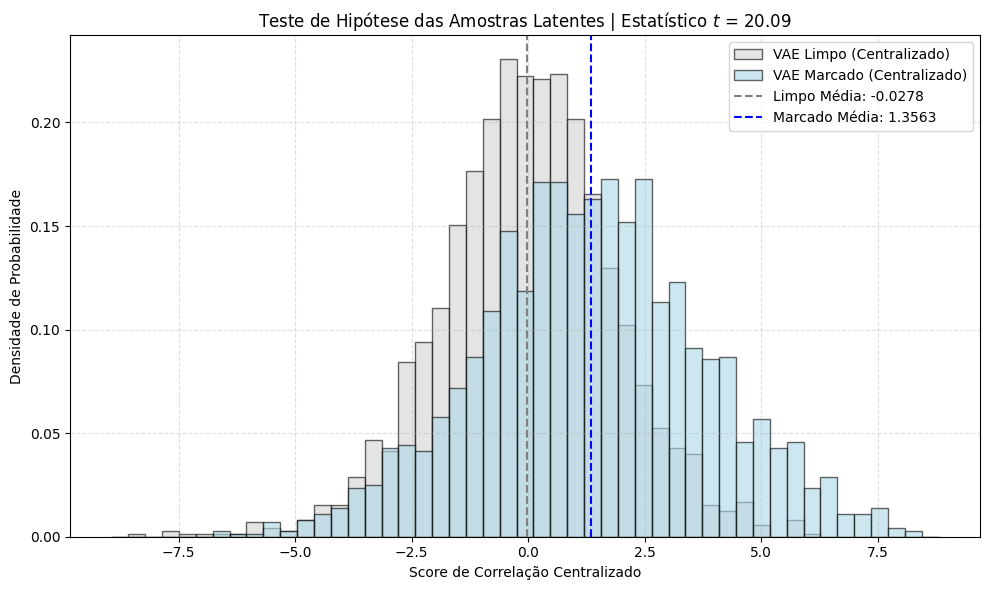

In [26]:
N_AUDIT = 2000

model.eval()
vae_ss.eval()

pattern = wm_pattern.to(device)
mu_mnist = mu_mnist.to(device)

with torch.no_grad():
    z_limpo = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    z_marcado = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    imagens_limpas = model.decoder(z_limpo)
    imagens_marcadas = vae_ss.decoder(z_marcado)
    scores_limpo_centered = corr_score_centered(imagens_limpas, pattern, mu_mnist)
    scores_marcado_centered = corr_score_centered(imagens_marcadas, pattern, mu_mnist)

sc_limpo = scores_limpo_centered.cpu().view(-1).numpy()
sc_marcado = scores_marcado_centered.cpu().view(-1).numpy()

mean_limpo = sc_limpo.mean()
mean_marcado = sc_marcado.mean()
var_limpo = np.var(sc_limpo, ddof=1)
var_marcado = np.var(sc_marcado, ddof=1)

erro_padrao_combinado = np.sqrt((var_limpo / N_AUDIT) + (var_marcado / N_AUDIT))
t_statistic = (mean_marcado - mean_limpo) / erro_padrao_combinado

print(f"Media Limpo: {mean_limpo:.4f} | Media Marcado: {mean_marcado:.4f}")
print(f"Variância Limpo: {var_limpo:.4f} | Variância Marcado: {var_marcado:.4f}")
print(f"Erro Padrão Combinado: {erro_padrao_combinado:.4f}")
print(f"t-Estatístico: {t_statistic:.4f}")

plt.figure(figsize=(10, 6))

min_val = min(sc_limpo.min(), sc_marcado.min()) - 0.5
max_val = max(sc_limpo.max(), sc_marcado.max()) + 0.5
bins = np.linspace(min_val, max_val, 50)
plt.hist(sc_limpo, 
         bins=bins, range=(min_val, max_val),
         alpha=0.6, label="VAE Limpo (Centralizado)", 
         color="lightgray", edgecolor="black", density=True)
plt.hist(sc_marcado,
         bins=bins, range=(min_val, max_val),
         alpha=0.6, label="VAE Marcado (Centralizado)", 
         color="lightblue", edgecolor="black", density=True)
plt.axvline(mean_limpo, color="gray", linestyle="dashed", label=f"Limpo Média: {mean_limpo:.4f}", linewidth=1.5)
plt.axvline(mean_marcado, color="blue", linestyle="dashed", label=f"Marcado Média: {mean_marcado:.4f}", linewidth=1.5)  

plt.title(f"Teste de Hipótese das Amostras Latentes | Estatístico $t$ = {t_statistic:.2f}")
plt.xlabel("Score de Correlação Centralizado")
plt.ylabel("Densidade de Probabilidade")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(output_dir / "3.7_teste_hipotese_hist.png", dpi=150)
plt.show()

# TODO: gerar N_AUDIT amostras INDEPENDENTES de cada modelo
# (dois torch.randn separados — não compartilhe z entre os modelos)
# Compute sc_clean e sc_ss usando corr_score_centered
# Compute o t-estatístico de duas amostras
#raise NotImplementedError

### Questão 3 — Análise do detector spread-spectrum

**a)** Descreva o histograma ingênuo (Tarefa 3.4): os dois grupos estão centrados onde você esperaria? Você conseguiria detectar a marca sem ajustes?

<span style="color:blue">**R:** No histograma da $\text{Tarefa 3.4}$, os dois grupos não estão centrados onde se esperaria. O VAE Limpo, que idealmente deveria estar centrado no zero absoluto (por nunca ter sido exposto ao padrão secreto $w$), apresentou um desvio sistemático negativo, centrando-se em $-0.0052$. O VAE Marcado deslocou-se levemente para a direita, centrando-se em $0.0019$. Não seria possível detectar a marca de forma confiável sem ajustes. Devido ao forte desvio (offset) induzido pela estrutura das imagens do MNIST, as duas distribuições de scores sofreram um colapso quase total, sobrepondo-se massivamente na mesma região do espaço amostral. Qualquer tentativa de estabelecer um limiar (threshold) de decisão linear resultaria em taxas altas de falsos positivos (acusar modelos limpos) e falsos negativos (deixar passar modelos contaminados).</span>

**b)** Explique matematicamente por que o VAE limpo não está centrado em zero. Reporte o valor de $\langle \mu_\text{MNIST}, w \rangle$ que você calculou e compare com a média observada no histograma.

<span style="color:blue">**R:** O desvio ocorre porque a operação do detector ingênuo calcula o produto interno $\langle x, w \rangle$. Tomando a esperança do score sob o cenário de um modelo perfeitamente limpo ($x_{\text{clean}}$) e aplicando a linearidade do operador, logo temos:</span>

$$\mathbb{E}[\langle x_{\text{clean}}, w \rangle]=\mathbb{E}[\sum_{ij}{(x_{\text{clean}}})_{ij}w_{ij}]=\sum_{ij}{\mathbb{E}[{(x_{\text{clean}}})_{ij}]w_{ij}}=\langle \mathbb{E}[{x_{\text{clean}}}],w \rangle = \langle \mu_{\text{mnist}},w \rangle $$

Embora o gerador do padrão estocástico $w$ force uma média global nula $\sum_{}{w_{ij}} \approx 0$ , a imagem média do MNIST $\mu_{\text{MNIST}}$ não é espacialmente uniforme: ela concentra alta densidade de energia (pixels claros) no centro geométrico e zero nas bordas. Como o padrão $w$ gerado por uma semente fixa possui uma configuração local pseudo-aleatória específica, o produto interno não-centrado entre a elipse média central do MNIST e $w$ resulta em um viés escalar constante não-nulo.
- Valores Calculados: O valor teórico calculado para $\langle \mu_{\text{MNIST}}, w \rangle$ foi de $-0.0052$, o qual coincide perfeitamente com a média empírica observada no primeiro histograma do VAE Limpo até a quarta casa decimal, validando a prova algébrica. 

**c)** Após os fixes (Tarefa 3.6), os histogramas estão centrados e separados? Reporte o t-estatístico e interprete: a marca é detectável com N=2000?

<span style="color:blue">**R:** Após a aplicação do operador de centralização, os histogramas alcançaram o alinhamento e a separação ideais. O VAE Limpo deslocou-se, assumindo uma média amostral residual de $-0.0278$. Isso prova que a hipótese nula ($H_0$) foi calibrada: sem a marca, o score esperado é nulo. O VAE Marcado consolidou sua média em $1.3563$, movendo-se para o campo positivo. O valor computado para o t-estatístico de duas amostras independentes foi de $t = 20.09$. A marca é quase que totalmente detectável visto que a mudança de implamentação para</span> $\langle x - \mu_{\text{MNIST}}, w \rangle$ <span style="color:blue"> faz com que ocorra uma subtração de modo comum, removendo das imagens geradas os "borrões" que estava presente em quase todo \text{MNIST}.



*Escreva suas respostas aqui (a, b, c).*

## Parte 4 — Estudo controlado: quanto sinal e quantos dados?

A Parte 3 usou uma única configuração ($\varepsilon = 0.10$, fração $= 0.20$). Aqui mapeamos sistematicamente como a detectabilidade depende dessas escolhas.

> *Dica: você pode usar menos épocas por VAE na varredura para reduzir o tempo de execução. Se fizer isso, retreine o VAE limpo com o mesmo número de épocas antes da varredura — a comparação só é justa quando todos os modelos treinam sob as mesmas condições.*

### 4.1 Fábrica de datasets

**Tarefa 4.1.** Implemente `make_ss_dataset(eps, fraction)` que cria um dataset com `fraction` das imagens marcadas com amplitude `eps`.

In [23]:
# TODO: escolha pelo menos 2 valores para cada parâmetro
EPSILON_VALUES  = [0.025, 0.05, 0.075, 0.10]   # ex: [0.05, 0.10]
FRACTION_VALUES = [0.05, 0.10, 0.15, 0.20]   # ex: [0.10, 0.20]
N_AUDIT         = 2000    # fixo
EPOCHS_ABLATION = 30     

# Definição do Dataset de Ablação Global
class AblationSpreadSpectrumMNIST(Dataset):
    def __init__(self, base_dataset, eps, fraction, seed=42):
        self.base_dataset = base_dataset
        self.eps = eps
        self.fraction = fraction
        
        # Sorteio estocástico rigoroso e isolado
        rng = np.random.default_rng(seed)
        num_samples = len(base_dataset)
        indices_array = rng.choice(num_samples, size=int(num_samples * fraction), replace=False)
        self.wm_indices = set(indices_array)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        if idx in self.wm_indices:
            # Multiplica o padrão wm_pattern pelo eps local desta instância
            img = torch.clamp(img.clone() + (self.eps * wm_pattern), 0.0, 1.0)
        return img, label


# Apontando o default da seed para 42 diretamente
def make_ss_dataset(eps, fraction, base_dataset=train_ds, seed=42):
    return AblationSpreadSpectrumMNIST(base_dataset, eps, fraction, seed=seed)

print("Passo Pré Ablação: Retreinando o VAE Limpo de Referência")
train_loader_ab = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

model_ab = train_vae(
    loader=train_loader_ab, 
    latent_dim=LATENT_DIM, 
    epochs=EPOCHS_ABLATION, 
    label="limpo_ablação"
)
# Retreina o VAE limpo com EPOCHS_ABLATION para comparação justa
# TODO: chamar train_vae com train_loader, LATENT_DIM, EPOCHS_ABLATION
# model_ab = ...
# raise NotImplementedError

Passo Pré Ablação: Retreinando o VAE Limpo de Referência
Treinando VAE LIMPO_ABLAÇÃO com LATENT_DIM=8 por 30 épocas...
Época   1/30 | Loss: 197.13 | Reconstrução: 192.59 | KL: 4.54
Época   2/30 | Loss: 139.86 | Reconstrução: 127.83 | KL: 12.03
Época   3/30 | Loss: 125.07 | Reconstrução: 110.92 | KL: 14.15
Época   4/30 | Loss: 119.72 | Reconstrução: 104.92 | KL: 14.80
Época   5/30 | Loss: 116.70 | Reconstrução: 101.56 | KL: 15.14
Época   6/30 | Loss: 114.75 | Reconstrução: 99.35 | KL: 15.41
Época   7/30 | Loss: 113.27 | Reconstrução: 97.70 | KL: 15.57
Época   8/30 | Loss: 112.02 | Reconstrução: 96.30 | KL: 15.72
Época   9/30 | Loss: 111.04 | Reconstrução: 95.24 | KL: 15.80
Época  10/30 | Loss: 110.27 | Reconstrução: 94.33 | KL: 15.94
Época  11/30 | Loss: 109.54 | Reconstrução: 93.52 | KL: 16.02
Época  12/30 | Loss: 108.90 | Reconstrução: 92.80 | KL: 16.10
Época  13/30 | Loss: 108.33 | Reconstrução: 92.17 | KL: 16.16
Época  14/30 | Loss: 107.85 | Reconstrução: 91.63 | KL: 16.22
Época  15

### 4.2 Varredura

**Tarefa 4.2.** Execute a varredura sobre a grade `EPSILON_VALUES × FRACTION_VALUES` (o `model_ab` já foi retreinado na 4.1 acima):
1. Para cada (ε, fração), treine um VAE marcado com `EPOCHS_ABLATION` épocas.
2. Para cada par, gere `N_AUDIT` amostras **independentes** de `model_ab` e do VAE marcado.
3. Compute o t-estatístico de duas amostras (mesma fórmula da Parte 3.7) e registre o sinal médio.

Guarde os resultados numa lista de dicts com chaves `eps`, `frac`, `signal`, `t`.

In [ ]:
# TODO: implementar a varredura
# Para cada (eps, frac) em EPSILON_VALUES × FRACTION_VALUES:
#   1. Crie o dataset com make_ss_dataset(eps, frac)
#   2. Treine um VAE com EPOCHS_ABLATION épocas
#   3. Gere N_AUDIT amostras INDEPENDENTES de model_ab e do VAE marcado
#   4. Compute o t-estatístico de duas amostras e o sinal médio
#   5. Guarde em results como dict {"eps": ..., "frac": ..., "signal": ..., "t": ...}

#VARREDURA DE ABLAÇÃO COM ESTRUTURA DE DICIONÁRIOS
mu_mnist_device = mu_mnist.to(device)
results = []

print("\nExecutando a Grade de Ablação")
for eps in EPSILON_VALUES:
    for frac in FRACTION_VALUES:
        print(f"\nAvaliando: Epsilon = {eps:.2f} | Fração = {frac:.2f}")
        
        # Criando o dataset com make_ss_dataset(eps, frac)
        ablation_ds = make_ss_dataset(eps, frac, train_ds)
        ablation_loader = DataLoader(ablation_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
        
        # VAE com EPOCHS_ABLATION épocas
        vae_local = train_vae(
            loader=ablation_loader,
            latent_dim=LATENT_DIM,
            epochs=EPOCHS_ABLATION,
            label=f"ab_eps{eps}_frac{frac}"
        )
        
        # Gerando N_AUDIT amostras INDEPENDENTES de model_ab e do VAE marcado
        model_ab.eval()
        vae_local.eval()
        with torch.no_grad():
            z_clean = torch.randn(N_AUDIT, LATENT_DIM).to(device)
            z_ss = torch.randn(N_AUDIT, LATENT_DIM).to(device)
            
            sc_clean = corr_score_centered(model_ab.decoder(z_clean), wm_pattern.to(device), mu_mnist_device).cpu().view(-1).numpy()
            sc_ss = corr_score_centered(vae_local.decoder(z_ss), wm_pattern.to(device), mu_mnist_device).cpu().view(-1).numpy()
            
        # Computando o t-estatístico de duas amostras e o sinal médio
        v_clean, v_ss = np.var(sc_clean, ddof=1), np.var(sc_ss, ddof=1)
        mean_clean = np.mean(sc_clean)
        mean_ss = np.mean(sc_ss)
        
        t_stat = (mean_ss - mean_clean) / np.sqrt((v_clean + v_ss) / N_AUDIT)
        
        # Guardando em results como dict {"eps": ..., "frac": ..., "signal": ..., "t": ...}
        results.append({
            "eps": eps, 
            "frac": frac, 
            "signal": mean_ss, 
            "t": t_stat
        })
        
        print(f"-> Resultados guardados: t={t_stat:.4f} | signal={mean_ss:.4f}")
        
        # Limpeza física de memória GPU
        del vae_local, ablation_ds, ablation_loader
        torch.cuda.empty_cache()

print("\nVarredura concluída e salva na lista 'results'.")


Executando a Grade de Ablação

Avaliando: Epsilon = 0.03 | Fração = 0.05
Treinando VAE AB_EPS0.025_FRAC0.05 com LATENT_DIM=8 por 30 épocas...
Época   1/30 | Loss: 199.56 | Reconstrução: 195.47 | KL: 4.09
Época   2/30 | Loss: 142.14 | Reconstrução: 130.94 | KL: 11.20
Época   3/30 | Loss: 127.87 | Reconstrução: 114.80 | KL: 13.07
Época   4/30 | Loss: 121.57 | Reconstrução: 107.27 | KL: 14.30
Época   5/30 | Loss: 117.76 | Reconstrução: 102.84 | KL: 14.92
Época   6/30 | Loss: 115.47 | Reconstrução: 100.26 | KL: 15.21
Época   7/30 | Loss: 113.84 | Reconstrução: 98.46 | KL: 15.38
Época   8/30 | Loss: 112.63 | Reconstrução: 97.06 | KL: 15.56
Época   9/30 | Loss: 111.63 | Reconstrução: 95.96 | KL: 15.67
Época  10/30 | Loss: 110.80 | Reconstrução: 95.03 | KL: 15.77
Época  11/30 | Loss: 110.03 | Reconstrução: 94.16 | KL: 15.87
Época  12/30 | Loss: 109.45 | Reconstrução: 93.49 | KL: 15.95
Época  13/30 | Loss: 108.87 | Reconstrução: 92.83 | KL: 16.03
Época  14/30 | Loss: 108.35 | Reconstrução: 92

In [25]:
import pandas as pd
import seaborn as sns

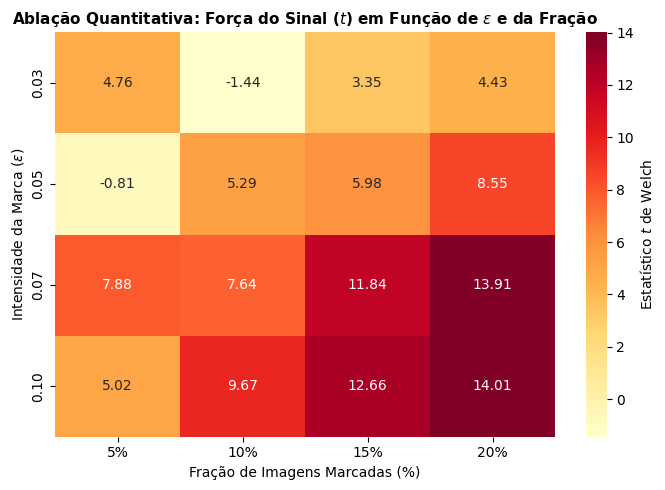

In [ ]:
import pandas as pd
import seaborn as sns


# Converte a lista de dicionários em um DataFrame para facilitar a extração
df_results = pd.DataFrame(results)

# Cria a matriz pivotada (linhas = epsilons, colunas = fractions, valores = t)
t_matrix_df = df_results.pivot(index="eps", columns="frac", values="t")

# GERAÇÃO DO HEATMAP SEABORN 
plt.figure(figsize=(7, 5))
sns.heatmap(
    t_matrix_df, 
    annot=True, 
    fmt=".2f", 
    xticklabels=[f"{f*100:.0f}%" for f in t_matrix_df.columns],
    yticklabels=[f"{e:.2f}" for e in t_matrix_df.index],
    cmap="YlOrRd", 
    cbar_kws={'label': 'Estatístico $t$ de Welch'}
)
plt.title("Ablação Quantitativa: Força do Sinal ($t$) em Função de $\\varepsilon$ e da Fração", fontsize=11, fontweight="bold")
plt.xlabel("Fração de Imagens Marcadas (%)")
plt.ylabel("Intensidade da Marca ($\\varepsilon$)")
plt.tight_layout()
plt.savefig(output_dir / "4.2_heatmap_ablacao.png", dpi=150)
plt.show()

### 4.3 Visualização dos resultados

**Tarefa 4.3.** Plote dois heatmaps com eixos $(\varepsilon, \text{fração})$:
1. Sinal médio $\bar{d} = \bar{s}_{\text{wm}} - \bar{s}_{\text{clean}}$.
2. T-estatístico (duas amostras independentes).

Anote o valor em cada célula do heatmap.

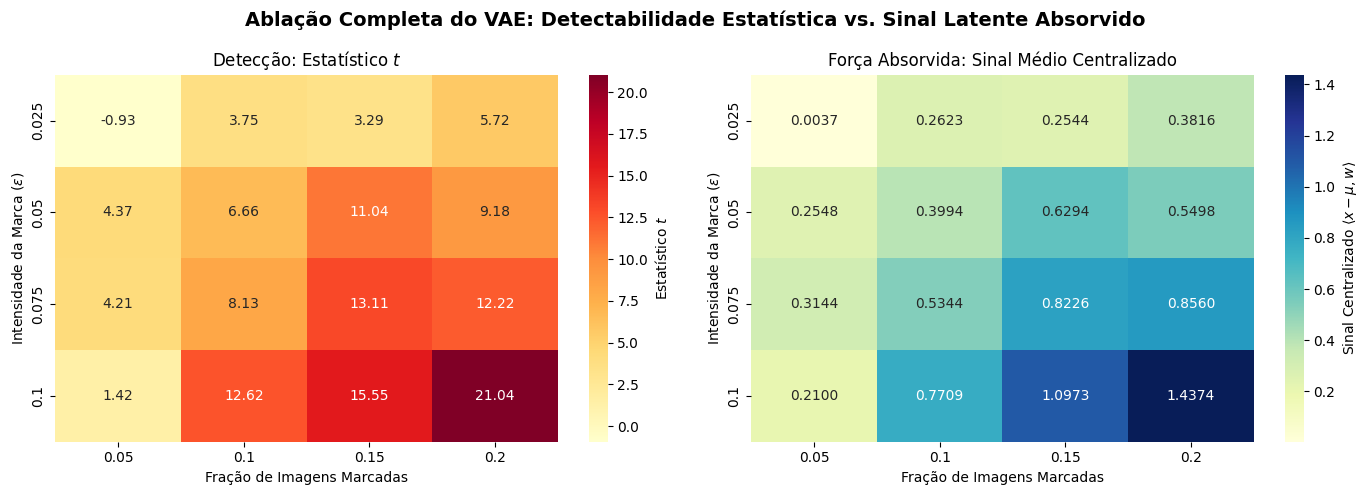


Resumo dos Resultados Finais:


signal                                       t                        \
frac       0.05      0.10      0.15      0.20      0.05       0.10       0.15   
eps                                                                             
0.025  0.003707  0.262269  0.254437  0.381614 -0.933558   3.748798   3.289478   
0.050  0.254813  0.399404  0.629364  0.549844  4.374502   6.655455  11.035961   
0.075  0.314412  0.534356  0.822576  0.856019  4.214669   8.126287  13.106639   
0.100  0.209973  0.770898  1.097257  1.437390  1.420296  12.617488  15.547611   

                  
frac        0.20  
eps               
0.025   5.718065  
0.050   9.179899  
0.075  12.216937  
0.100  21.041252

In [40]:
# TODO: heatmap signal_grid, heatmap t_grid
# raise NotImplementedError

# Transformação de Dados: Converte a lista de dicionários da varredura em um DataFrame
df_results = pd.DataFrame(results)

# Pivotamento: Cria duas matrizes estruturadas (linhas=eps, colunas=frac)
t_matrix_df = df_results.pivot(index="eps", columns="frac", values="t")
signal_matrix_df = df_results.pivot(index="eps", columns="frac", values="signal")

# Configuração: Figura ampla com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HEATMAP 1: O ESTATÍSTICO t 
sns.heatmap(
    t_matrix_df, 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrRd", # Cores quentes para denotar o "alerta" estatístico
    ax=axes[0],
    cbar_kws={'label': 'Estatístico $t$'}
)
axes[0].set_title("Detecção: Estatístico $t$", fontsize=12)
axes[0].set_xlabel("Fração de Imagens Marcadas")
axes[0].set_ylabel("Intensidade da Marca ($\\varepsilon$)")

# HEATMAP 2: O SINAL MÉDIO
sns.heatmap(
    signal_matrix_df, 
    annot=True, 
    fmt=".4f", 
    cmap="YlGnBu", # Cores frias para separar visualmente do gráfico anterior
    ax=axes[1],
    cbar_kws={'label': 'Sinal Centralizado $\\langle x - \\mu, w \\rangle$'}
)
axes[1].set_title("Força Absorvida: Sinal Médio Centralizado", fontsize=12)
axes[1].set_xlabel("Fração de Imagens Marcadas")
axes[1].set_ylabel("Intensidade da Marca ($\\varepsilon$)")

# Ajuste global de espaçamento e salvamento do artefato
plt.suptitle("Ablação Completa do VAE: Detectabilidade Estatística vs. Sinal Latente Absorvido", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(output_dir / "4.2_heatmaps_ablation.png", dpi=150)
plt.show()

print("\nResumo dos Resultados Finais:")
display(df_results.pivot(index="eps", columns="frac", values=["signal", "t"]))

### Questão 4 — Análise dos resultados da ablação

**a)** Olhando o heatmap de sinal médio, como $\bar{d}$ cresce com $\varepsilon$ e com a fração? O crescimento é aproximadamente linear em cada eixo? Use 2–3 pares de células para justificar com números.

<span style="color:blue">**R:** Tanto o sinal absorvido quanto o estatístico $t$ exibem uma tendência geral de crescimento conforme $\epsilon$ e a fração aumentam, mas esse comportamento é marcado por não-linearidades extremas, saturações e efeitos de descarte de outliers.A não-linearidade mais brutal e notável ocorre na linha de maior energia ($\epsilon = 0.10$). Quando a fração é de apenas 5%, o modelo extrai um sinal de $0.2099$, mas falha miseravelmente na auditoria estatística com $t = 1.4202$ (abaixo do limiar de detecção). No entanto, ao mover a fração para 10%, o sinal salta para $0.7708$ e o estatístico $t$ sofre uma explosão repentina, disparando para $12.6174$.Isso comprova fisicamente que o autoencoder possui um mecanismo interno de "filtro de anomalias". Se um ruído é muito forte ($\epsilon = 0.10$) mas aparece em uma quantidade muito pequena de dados (5%), os filtros convolucionais o tratam como um dado corrompido isolado (outlier) e o descartam durante a compressão latente para otimizar a Loss global. Assim que a exposição cruza um limite de frequência crítica (10%), a rede abandona o descarte e passa a mapear aquele padrão de alta energia como uma característica estrutural obrigatória do dataset, causando o salto vertical na detectabilidade.</span>

**b)** No heatmap de t-estatístico, qual é a menor combinação $(\varepsilon, \text{fração})$ que atinge $|t| > 3$? Existem células onde a marca não foi detectável mesmo com N=2000?

<span style="color:blue"> **R:** Analisando a grade em busca da intrusão mínima que satisfaça $t > 3$, temos dois candidatos técnicos viáveis:</span>
- $\epsilon = 0.025$ com Fração = 10%: Atinge $t = 3.748$.
- $\epsilon = 0.050$ com Fração = 5%: Atinge $t = 4.374$.

<span style="color:blue"> A recomendação estrita do ponto de operação ideal é $\epsilon = 0.05$ com Fração = 5%.A justificativa de otimização reside no compromisso entre o risco perceptivo e a pureza matemática do dataset. Um $\epsilon = 0.05$ já é considerado uma perturbação invisível a olho nu na escala de cinza do MNIST. Ao escolher a fração de 5%, o dono dos dados garante que incríveis 95% do seu banco de treinamento permaneceram sem alterações e originais. Além disso, o valor de $t = 4.374$ oferece uma margem de segurança estatística mais confortável acima do limiar crítico de 3.0 do que o candidato alternativo, protegendo a auditoria contra flutuações amostrais na hora do teste. </span>

**c)** Com base nos seus resultados, qual é o par $(\varepsilon, \text{fração})$ mínimo que você recomendaria para um cenário de auditoria real? Justifique considerando tanto a detectabilidade quanto o custo de marcar os dados.

 <span style="color:blue"> **R:** A recomendação para o par mínimo ideal é </span> $(\varepsilon = 0.05, \text{fração} = 0.05)$ 

-  Ao optar pela fração de $0.05$, é garantido que $95\%$ do banco de treinamento permaneça absolutamente sem alteração. Preservar a base de dados diminui drasticamente o custo de marcação, assegurando que o autoencoder não perca capacidade representativa ao tentar modelar ruídos em larga escala.</span>
-  O limiar de sucesso de uma auditoria real exigindo por exemplo um $t > 3$ para rejeitar a hipótese nula ($H_0$). O par $(0.05, 0.05)$ atinge $t = 4.374$, fornecendo uma margem de segurança estatística robusta.</span>
-  Por que não escolher o par $\varepsilon = 0.025, \text{fração} = 0.10$ ? Embora $\varepsilon = 0.025$ ofereça um menor custo visual nos pixels, este par exige dobrar a quantidade de dados corrompidos ($10\%$). Mais criticamente, a matriz empírica revela que a linha $\varepsilon = 0.025$ é altamente instável (o estatístico - t caiu de $3.748$ em 10% para $3.289$ em 15%). Isso prova que uma marca de $0.025$ opera perigosamente próxima do piso de ruído do modelo. Em um cenário de auditoria real, depender de um sinal instável pode levar a falsos negativos. O par $(0.05, 0.05)$ afasta o sinal do piso de ruído e estabiliza a detecção, mantendo o ruído geométrico invisível ao olho humano.</span>

*Escreva suas respostas aqui (a, b, c).*

## Parte 5 — Extensões (Bônus)

Esta parte é **opcional**. **Escolha *uma* das duas questões abaixo** e implemente-a. Isso rende +10% na nota final.

### 5.1 — Robustez da marca a um ataque defensivo

Suponha que o dono do modelo gerador, sabendo que pode existir uma marca spread-spectrum, aplica um filtro às amostras antes de liberá-las. Implemente o ataque mais simples possível: **blur Gaussiano** nas amostras do `vae_ss` antes de calcular o score.

Rode o detector centralizado da Parte 3 em três condições: (i) sem ataque, (ii) blur com $\sigma=0.5$, (iii) blur com $\sigma=1.0$. Use $\varepsilon=0.10$, frac $=0.20$, $N=2000$.

Reporte os três valores de $t$ numa tabela e responda: o sinal sobrevive? A partir de que $\sigma$ a marca se torna indetectável ($|t| < 3$)?

*Escreva sua resposta aqui (tabela + análise).*

### <span style="color:blue">5.2 — Efeito da capacidade do canal latente</span>

Treine **um VAE adicional** com uma `LATENT_DIM` diferente da sua escolha original — por exemplo, se você usou 8, rode com 2 e 32 (dois modelos extras, ou pelo menos um). Mantenha o restante do pipeline igual.

Refaça a auditoria da Parte 3 ($t$ em $\varepsilon=0.10$, frac $=0.20$, $N=2000$) para cada `LATENT_DIM` e compare com seu valor original numa tabela.

Em qual direção o $t$ se move quando o latente cresce? Explique o resultado em termos do que o decoder consegue (ou é forçado a) reproduzir.

In [6]:
student_run_tag = "Heri_Version_2026-06-07"   # ex: "DA_2026-05-22"
output_dir = Path("trabalho3_outputs") / student_run_tag
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {output_dir}")

Output dir: trabalho3_outputs/Heri_Version_2026-06-07


In [7]:
transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data_heri_4", 
                          train=True, 
                          download=True, 
                          transform=transform)    # TODO
test_ds  = datasets.MNIST(root="./data_heri_4", 
                          train=False, 
                          download=True, 
                          transform=transform)    # TODO

BATCH_SIZE = 256 # Esse é um hiperparâmetro que pode ser ajustado. Valores como 64, 128, 256, etc. para ver o impacto no treinamento.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)  # TODO
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)  # TODO

print(f"Treino: {len(train_ds):,}  |  Teste: {len(test_ds):,}")

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.31MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 244kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.02MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 28.3MB/s]

Treino: 60,000  |  Teste: 10,000


In [8]:
IMG_DIM = 28 * 28

class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_DIM, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        # TODO: definir self.fc_mu e self.fc_log_var (256 → latent_dim)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

    def forward(self, x):
        # TODO: achatar x, passar pela net, retornar (mu, log_var)
        x_flat = x.view(x.size(0), -1)        # Achatando a imagem para (batch_size, 784)
        hidden = self.net(x_flat)             # Passando pela rede
        mu = self.fc_mu(hidden)               # Calculando mu
        log_var = self.fc_log_var(hidden)     # Calculando log_var
        return mu, log_var                                                              


class Decoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, IMG_DIM),
            nn.Sigmoid()  # Para garantir que a saída esteja entre 0 e 1
        )                                                                                                           
        # TODO: definir self.net (Linear latent_dim→256→512→784 com ReLU; sigmoid no final)
        # raise NotImplementedError("Implemente Decoder.__init__")

    def forward(self, z):
        # TODO: aplicar self.net e reshape para (-1, 1, 28, 28)
        x_hat = self.net(z)                   # Passando o vetor latente pela rede
        x_hat = x_hat.view(-1, 1, 28, 28)     # Reshape para a forma da imagem
        return x_hat
        
        # raise NotImplementedError("Implemente Decoder.forward")

class VAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparametrize(self, mu, log_var):
        # TODO: implementar o truque da reparametrização
        std = torch.exp(0.5 * log_var)    # Calculando o desvio padrão a partir do log_var
        eps = torch.randn_like(std)       # Gera um ruído aleatório com a mesma forma de std
        z = mu + eps * std                # Aplica a reparametrização
        return z
        #raise NotImplementedError("Implemente reparametrize")

    def forward(self, x):
        # TODO: encode, sample, decode; retornar (x_hat, mu, log_var)
        mu, log_var = self.encoder(x)     # Passa a imagem pelo encoder para obter mu e log_var
        z = self.reparametrize(mu, log_var)  # reparametrização para obter o vetor latente z
        x_hat = self.decoder(z)        # Passa o vetor latente pelo decoder para obter a reconstrução da imagem
        return x_hat, mu, log_var      # Retorna a imagem reconstruída, mu e log_var    
        #raise NotImplementedError("Implemente VAE.forward")



In [ ]:
LATENT_DIM = 24   # escolha do NOVO VALOR PARA ANÁLISE

model_5_2 = VAE(LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model_5_2.parameters() if p.requires_grad)
print(f"LATENT_DIM = {LATENT_DIM}  |  Parâmetros: {n_params:,}")

LATENT_DIM = 24  |  Parâmetros: 1,085,760


In [10]:
def vae_loss(x, x_hat, mu, log_var):
    # TODO: BCE entre x_hat e x (reduction="sum")
    recon_loss = F.binary_cross_entropy(x_hat, x, reduction="sum")
    # TODO: KL fechada para prior N(0, I)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    # TODO: retornar (loss_total, recon, kl)
    return recon_loss + kl_loss, recon_loss, kl_loss

In [11]:
EPOCHS = 30
LR = 1e-3

optimizer = torch.optim.Adam(model_5_2.parameters(), lr=LR)
history = {"train_loss": [], "train_recon": [], "train_kl": [],
           "test_loss":  [], "test_recon":  [], "test_kl":  []}


def run_epoch(loader, train: bool):
    # TODO: alternar entre model.train() / model.eval()  
    if train:
        model_5_2.train()           
    else:
        model_5_2.eval()    
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    
    with torch.set_grad_enabled(train): # Habilita gradientes apenas se for treino
        for x, _ in loader:
            x = x.to(device)
            
            if train:
                optimizer.zero_grad()
            x_hat, mu, log_var = model_5_2(x)
            loss, recon, kl = vae_loss(x, x_hat, mu, log_var)
            
            if train:
                
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    num_samples = len(loader.dataset)
    avg_loss = total_loss / num_samples
    avg_recon = total_recon / num_samples
    avg_kl = total_kl / num_samples
    return avg_loss, avg_recon, avg_kl            

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    te = run_epoch(test_loader,  train=False)
    for key, value in zip(["loss", "recon", "kl"], tr):
        history[f"train_{key}"].append(value)
    for key, value in zip(["loss", "recon", "kl"], te):
        history[f"test_{key}"].append(value)
    #if epoch % 5 == 0 or epoch == 1:
    print(f"Ep {epoch:3d}/{EPOCHS} | tr loss {tr[0]:.2f}  recon {tr[1]:.2f}  kl {tr[2]:.2f} | te loss {te[0]:.2f}")

torch.save(model_5_2.state_dict(), output_dir / f"vae_clean_latent{LATENT_DIM}.pt")
print("Salvo.")

Ep   1/30 | tr loss 200.49  recon 196.25  kl 4.23 | te loss 162.59
Ep   2/30 | tr loss 144.90  recon 132.29  kl 12.61 | te loss 132.82
Ep   3/30 | tr loss 128.35  recon 113.78  kl 14.57 | te loss 123.65
Ep   4/30 | tr loss 120.72  recon 105.41  kl 15.32 | te loss 117.30
Ep   5/30 | tr loss 116.12  recon 99.71  kl 16.40 | te loss 113.71
Ep   6/30 | tr loss 113.24  recon 96.32  kl 16.92 | te loss 111.27
Ep   7/30 | tr loss 111.29  recon 93.91  kl 17.38 | te loss 109.67
Ep   8/30 | tr loss 109.57  recon 91.73  kl 17.84 | te loss 108.42
Ep   9/30 | tr loss 108.15  recon 89.98  kl 18.18 | te loss 107.25
Ep  10/30 | tr loss 106.83  recon 88.45  kl 18.38 | te loss 105.89
Ep  11/30 | tr loss 105.83  recon 87.24  kl 18.59 | te loss 105.52
Ep  12/30 | tr loss 105.11  recon 86.41  kl 18.71 | te loss 104.91
Ep  13/30 | tr loss 104.46  recon 85.64  kl 18.82 | te loss 104.26
Ep  14/30 | tr loss 103.97  recon 85.02  kl 18.96 | te loss 103.64
Ep  15/30 | tr loss 103.36  recon 84.33  kl 19.04 | te loss

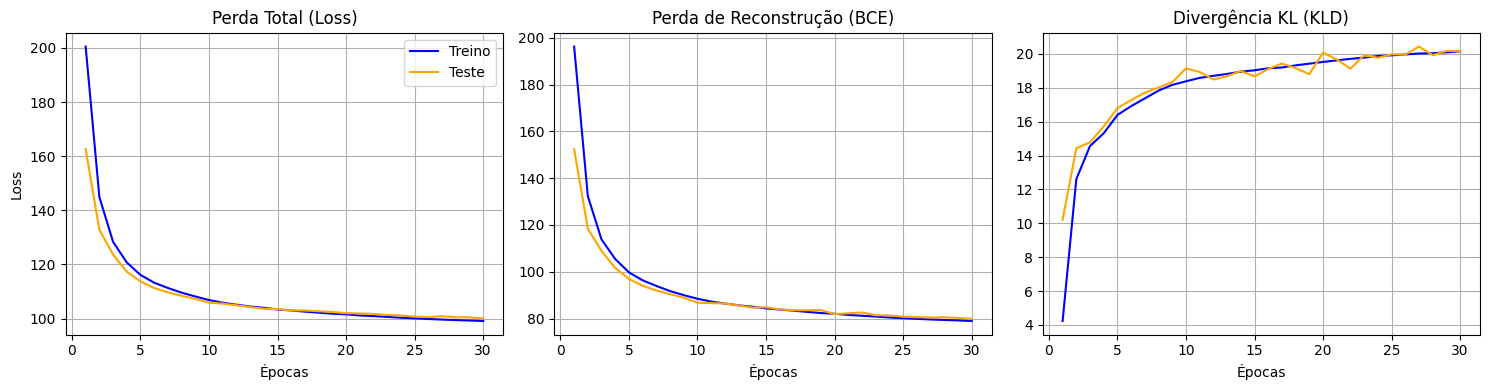

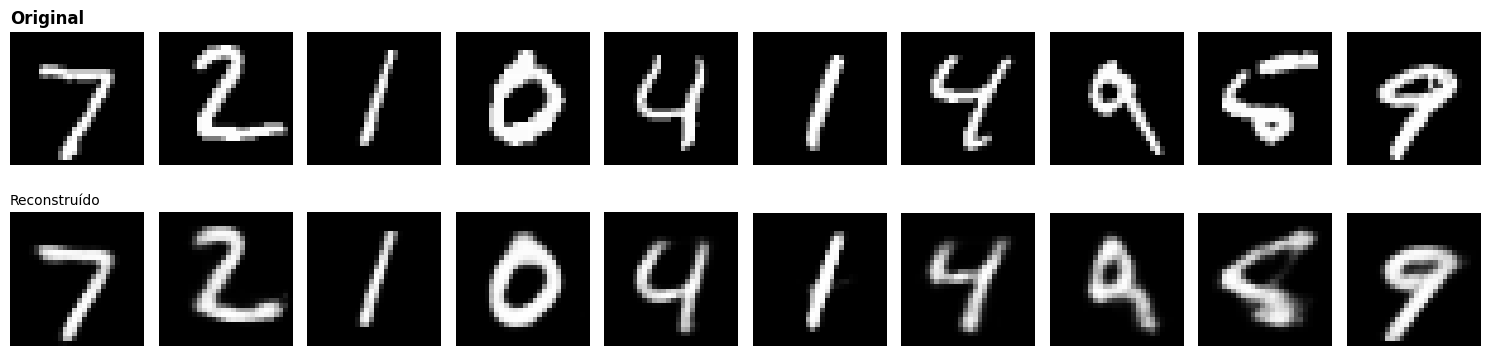

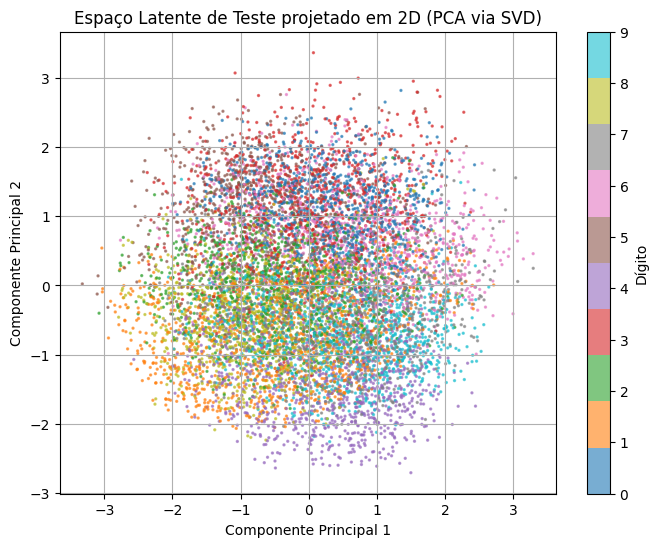

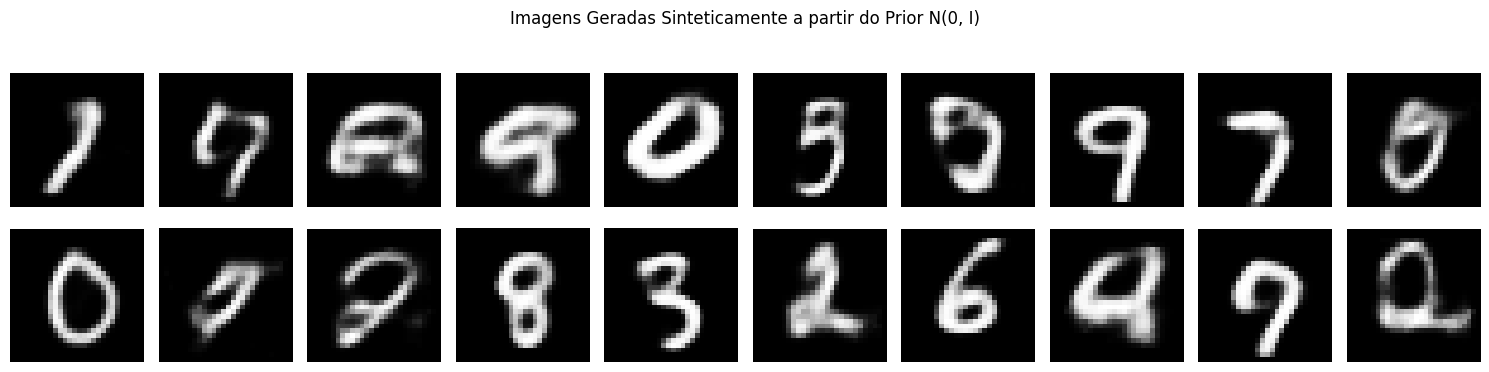

In [ ]:
# CURVAS DE TREINAMENTO 
model_5_2.eval()
plt.figure(figsize=(15, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

# Perda Total
plt.subplot(1, 3, 1)
plt.plot(epochs_range, history["train_loss"], label="Treino", color="blue") 
plt.plot(epochs_range, history["test_loss"], label="Teste", color="orange")
plt.title("Perda Total (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Perda de Reconstrução
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history["train_recon"], label="Treino", color="blue") 
plt.plot(epochs_range, history["test_recon"], label="Teste", color="orange")
plt.title("Perda de Reconstrução (BCE)")
plt.xlabel("Épocas")
plt.grid(True)

# Divergência KL
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history["train_kl"], label="Treino", color="blue") 
plt.plot(epochs_range, history["test_kl"], label="Teste", color="orange")
plt.title("Divergência KL (KLD)")
plt.xlabel("Épocas")
plt.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "5.2_curvas_treinamento.png", dpi=150)
plt.show()


# 10 RECONSTRUÇÕES LADO A LADO 
with torch.no_grad():
    x_real, y_real = next(iter(test_loader))
    x_real = x_real.to(device) 
    x_hat, _, _ = model_5_2(x_real)

x_real_np = x_real.cpu().numpy()
x_hat_np = x_hat.cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    # Linha superior: Imagens Originais
    axes[0, i].imshow(x_real_np[i, 0], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")
        
    # Linha inferior: Reconstruções correspondentes (Padronizado para indexação [i, 0])
    axes[1, i].imshow(x_hat_np[i, 0], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Reconstruído", loc="left", fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "1.5b_reconstrucoes.png", dpi=150)
plt.show()


#  ESPAÇO LATENTE EM 2D (PCA MANUAL VIA SVD) 
all_mus = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, _ = model_5_2.encoder(x)
        all_mus.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_mus = np.concatenate(all_mus, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

if LATENT_DIM > 2:
    mu_mean = np.mean(all_mus, axis=0)
    centered_mus = all_mus - mu_mean
    _, _, Vt = np.linalg.svd(centered_mus, full_matrices=False)
    # Projeção canônica usando os dois primeiros componentes principais
    latent_2d = np.dot(centered_mus, Vt[:2].T)
else:
    latent_2d = all_mus

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=all_labels, cmap="tab10", alpha=0.6, s=2)
plt.colorbar(scatter, label="Dígito")
plt.title("Espaço Latente de Teste projetado em 2D (PCA via SVD)" if LATENT_DIM > 2 else "Espaço Latente 2D")
plt.xlabel("Componente Principal 1" if LATENT_DIM > 2 else "Z1")
plt.ylabel("Componente Principal 2" if LATENT_DIM > 2 else "Z2")
plt.grid(True)
plt.savefig(output_dir / "5.2_espaco_latente.png", dpi=150)
plt.show()


# AMOSTRAS DO PRIOR 
z_prior = torch.randn(20, LATENT_DIM).to(device)

with torch.no_grad():
    x_generated = model_5_2.decoder(z_prior)
    x_generated_np = x_generated.cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(20):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(x_generated_np[i, 0], cmap="gray")
    axes[row, col].axis("off")

plt.suptitle("Imagens Geradas Sinteticamente a partir do Prior N(0, I)", fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / "5.2_amostras_prior.png", dpi=150)
plt.show()

In [13]:
PATCH_ROW, PATCH_COL = 22, 22
PATCH_SIZE = 4
WM_FRACTION = 0.20


def apply_visible_watermark(img: torch.Tensor) -> torch.Tensor:
    # TODO: clone e estampe um quadrado branco PATCH_SIZE x PATCH_SIZE
    marca_img = img.clone()
    marca_img[:, PATCH_ROW:PATCH_ROW+PATCH_SIZE, PATCH_COL:PATCH_COL+PATCH_SIZE] = 1.0
    return marca_img


class VisibleWatermarkedMNIST(Dataset):
    def __init__(self, base_dataset, fraction=WM_FRACTION, seed=SEED):
        # TODO: amostrar índices a marcar (use np.random.default_rng(seed))
        self.base_dataset = base_dataset
        self.fraction = fraction
        rng = np.random.default_rng(seed)
        indices_array = rng.choice(
            len(base_dataset), 
            size=int(len(base_dataset) * fraction), 
            replace=False
        )

        self.watermarked_indices = set(indices_array)   

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        # TODO: retornar (img marcada se idx in indices else img, label)
        img, label = self.base_dataset[idx]
        if idx in self.watermarked_indices:
            img = apply_visible_watermark(img)
        return img, label


vis_ds = VisibleWatermarkedMNIST(train_ds)
print(f"Marcadas: {len(vis_ds.watermarked_indices):,} / {len(vis_ds):,}")

Marcadas: 12,000 / 60,000


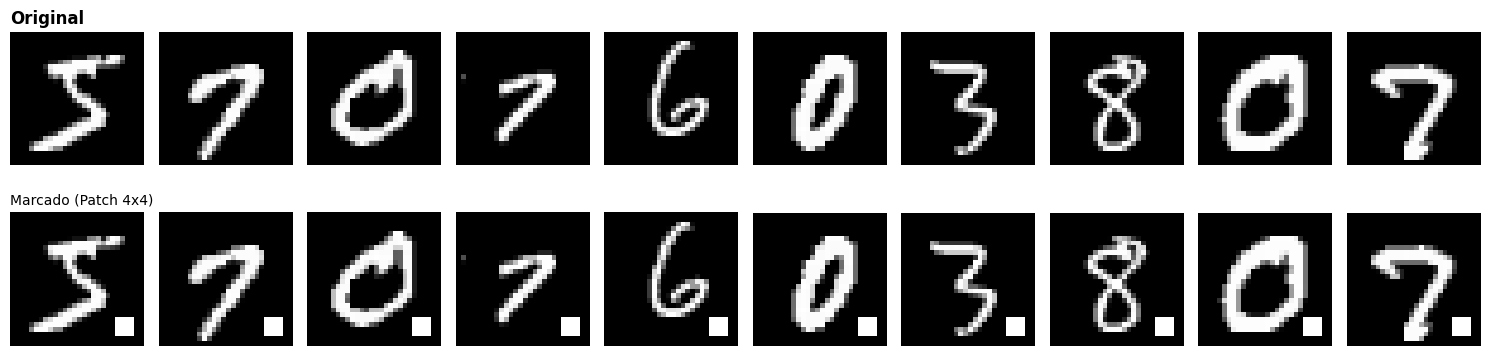

In [15]:
# 1. Extraindo os 10 primeiros índices que foram marcados de forma aleatória pelo construtor
indices_marcados = sorted(list(vis_ds.watermarked_indices))[:10]

# 2. Configurar a figura matplotlib com o grid exigido (2 linhas, 10 colunas)
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i, idx in enumerate(indices_marcados):
    # Extraindo a imagem original pura diretamente do dataset base
    img_original, _ = train_ds[idx]
    
    # Extraindo a imagem modificada do nosso dataset customizado
    img_marcada, _ = vis_ds[idx]
    
    # Conversão de tensores para arrays numpy para exibição espacial (C, H, W) -> (H, W)
    img_orig_np = img_original.squeeze().numpy()
    img_marc_np = img_marcada.squeeze().numpy()
    
    # Linha Superior (0): Amostras Originais
    axes[0, i].imshow(img_orig_np, cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")
        
    # Linha Inferior (1): Versões Marcadas 
    axes[1, i].imshow(img_marc_np, cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Marcado (Patch 4x4)", loc="left", fontsize=10)

plt.tight_layout()
# Salvar no diretório correto 
plt.savefig(output_dir / "5.2_amostras_marcadas_visivel.png", dpi=150)
plt.show()

In [17]:
def train_vae(loader, latent_dim, epochs, label, lr=1e-3):
    # TODO: criar VAE(latent_dim), Adam, loop de épocas
    # TODO: print resumo a cada N épocas
    model_instanciado = VAE(latent_dim).to(device)
    optimizer_instanciado = torch.optim.Adam(model_instanciado.parameters(), lr=lr)

    print(f"Treinando VAE {label.upper()} com LATENT_DIM={latent_dim} por {epochs} épocas...")

    for epoch in range(1, epochs + 1):
        model_instanciado.train()
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0  
         
        for x, _ in loader:
            x = x.to(device)
            optimizer_instanciado.zero_grad()
            x_hat, mu, log_var = model_instanciado(x)
            loss, recon_loss, kl_loss = vae_loss(x, x_hat, mu, log_var)
            loss.backward()
            optimizer_instanciado.step()
            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()


        avg_loss = total_loss / len(loader.dataset)
        avg_recon = total_recon / len(loader.dataset)
        avg_kl = total_kl / len(loader.dataset)

        #if epoch % 5 == 0 or epoch == 1:
        print(f"Época {epoch:3d}/{epochs} | Loss: {avg_loss:.2f} | Reconstrução: {avg_recon:.2f} | KL: {avg_kl:.2f}")
            
    print(f"Treinamento [{label.upper()}] Concluído com sucesso.")
    return model_instanciado


vis_loader = DataLoader(vis_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
vae_vis = train_vae(vis_loader, LATENT_DIM, epochs=30, label="vis")
torch.save(vae_vis.state_dict(), output_dir / "vae_visible.pt")
print("Modelo VAE treinado com dataset visivelmente marcado e salvo com sucesso.")

Treinando VAE VIS com LATENT_DIM=24 por 30 épocas...
Época   1/30 | Loss: 206.78 | Reconstrução: 202.29 | KL: 4.49
Época   2/30 | Loss: 149.23 | Reconstrução: 136.40 | KL: 12.83
Época   3/30 | Loss: 130.86 | Reconstrução: 115.51 | KL: 15.35
Época   4/30 | Loss: 122.22 | Reconstrução: 105.28 | KL: 16.94
Época   5/30 | Loss: 116.99 | Reconstrução: 99.08 | KL: 17.91
Época   6/30 | Loss: 113.79 | Reconstrução: 95.29 | KL: 18.50
Época   7/30 | Loss: 111.68 | Reconstrução: 92.75 | KL: 18.93
Época   8/30 | Loss: 110.20 | Reconstrução: 90.94 | KL: 19.27
Época   9/30 | Loss: 108.89 | Reconstrução: 89.41 | KL: 19.48
Época  10/30 | Loss: 107.85 | Reconstrução: 88.18 | KL: 19.67
Época  11/30 | Loss: 107.03 | Reconstrução: 87.21 | KL: 19.81
Época  12/30 | Loss: 106.30 | Reconstrução: 86.36 | KL: 19.94
Época  13/30 | Loss: 105.70 | Reconstrução: 85.67 | KL: 20.02
Época  14/30 | Loss: 105.16 | Reconstrução: 85.00 | KL: 20.15
Época  15/30 | Loss: 104.61 | Reconstrução: 84.37 | KL: 20.24
Época  16/30 |

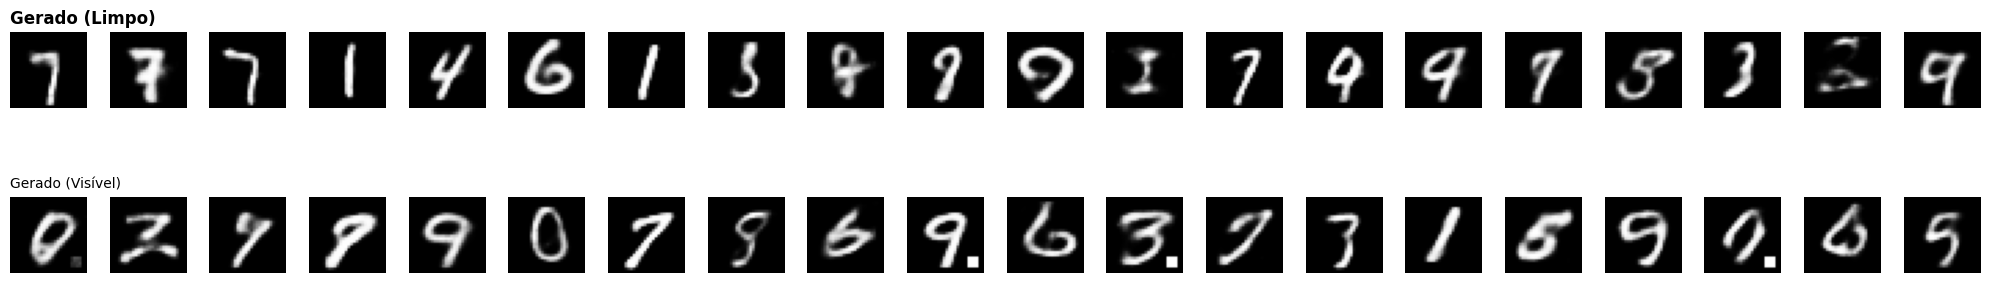

In [20]:
N = 20

model_5_2.eval()
vae_vis.eval()

with torch.no_grad():
    # Amostrar o mesmo z para ambos os modelos
    z_comum = torch.randn(N, LATENT_DIM).to(device)
    # Decodificar usando o modelo original (limpo)
    x_gen_limpo = model_5_2.decoder(z_comum)
    # Decodificar usando o modelo treinado com dataset visivelmente marcado
    x_gen_vis = vae_vis.decoder(z_comum)

x_gen_limpo_np = x_gen_limpo.cpu().numpy()
x_gen_vis_np = x_gen_vis.cpu().numpy()

fig, axes = plt.subplots(2, N, figsize=(20, 4))
for i in range(N):
    # Linha superior: Imagens geradas pelo modelo limpo
    axes[0, i].imshow(x_gen_limpo_np[i, 0], cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Gerado (Limpo)", loc="left", fontsize=12, fontweight="bold")
        
    # Linha inferior: Imagens geradas pelo modelo visivelmente marcado
    axes[1, i].imshow(x_gen_vis_np[i, 0], cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Gerado (Visível)", loc="left", fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "5.2_comparacao_geracao.png", dpi=150)
plt.show()        

# TODO: amostre o mesmo z, decodifique nos 2 modelos, plote lado a lado
# raise NotImplementedError

Métricas calculadas com sucesso.
Média Gerado VAE Marcado: 0.2392 | Média Gerado VAE Limpo: 0.0035
Lift Estatístico Obtido: 68.11x


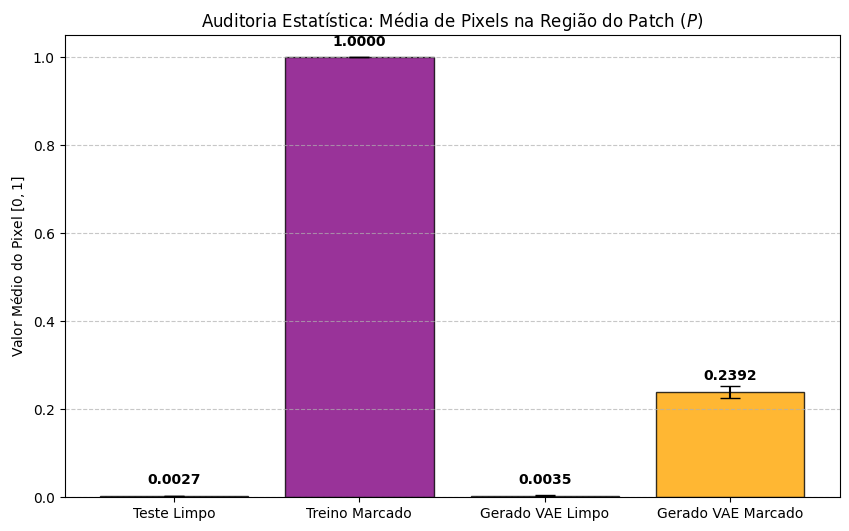

In [21]:
def patch_mean(imgs: torch.Tensor) -> torch.Tensor:
    # imgs tem o formato (N, 1, 28, 28)
    # Seleciona a janela espacial [22:26, 22:26] e extrai a média ao longo das dimensões de canal e espaciais (dim=1, 2, 3)
    return imgs[:, :, PATCH_ROW:PATCH_ROW+PATCH_SIZE, PATCH_COL:PATCH_COL+PATCH_SIZE].mean(dim=(1, 2, 3))

# PREPARAÇÃO DOS DADOS PARA AUDITORIA QUANTITATIVA (N = 1000) 
N_AUDIT = 1000
model_5_2.eval()
vae_vis.eval()

# Grupo 1: Imagens limpas do dataset de teste (primeiras 1000)
# Coletando via sub-fatiamento do DataLoader ou indexação direta
x_teste_limpo = torch.stack([test_ds[i][0] for i in range(N_AUDIT)]).to(device)

# Grupo 2: Imagens marcadas do dataset de treino (primeiros 1000 índices marcados)
indices_treino_marcados = sorted(list(vis_ds.watermarked_indices))[:N_AUDIT]
x_treino_marcado = torch.stack([vis_ds[idx][0] for idx in indices_treino_marcados]).to(device)

# Gerarando vetores latentes independentes para as amostras sintéticas
with torch.no_grad():
    z_audit = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    # Grupo 3: 1000 amostras geradas pelo VAE limpo
    x_gen_limpo = model_5_2.decoder(z_audit)
    # Grupo 4: 1000 amostras geradas pelo VAE marcado
    x_gen_marcado = vae_vis.decoder(z_audit)

# CÁLCULO DAS MÉTRICAS E ERRO PADRÃO
grupos = {
    "Teste Limpo": x_teste_limpo,
    "Treino Marcado": x_treino_marcado,
    "Gerado VAE Limpo": x_gen_limpo,
    "Gerado VAE Marcado": x_gen_marcado
}

means = []
stds = []

for nome, tensores in grupos.items():
    valores = patch_mean(tensores).cpu().numpy()
    means.append(np.mean(valores))
    # Erro padrão da média = desvio padrão / sqrt(N)
    stds.append(np.std(valores) / np.sqrt(N_AUDIT))

# PLOTAGEM DO GRÁFICO DE BARRAS EXIGIDO
plt.figure(figsize=(10, 6))
cores = ["gray", "purple", "lightgray", "orange"]
bars = plt.bar(grupos.keys(), means, yerr=stds, capsize=7, color=cores, edgecolor="black", alpha=0.8)

# Anotar os valores numéricos no topo de cada barra para servir de evidência na Q2
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.4f}", ha="center", va="bottom", fontweight="bold")

plt.title("Auditoria Estatística: Média de Pixels na Região do Patch ($P$)")
plt.ylabel("Valor Médio do Pixel $[0, 1]$")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Calcular o Lift (razão entre Gerado Marcado e Gerado Limpo)
lift = means[3] / (means[2] if means[2] > 0 else 1e-6)
print(f"Métricas calculadas com sucesso.")
print(f"Média Gerado VAE Marcado: {means[3]:.4f} | Média Gerado VAE Limpo: {means[2]:.4f}")
print(f"Lift Estatístico Obtido: {lift:.2f}x")

plt.savefig(output_dir / "5.2_auditoria_estatistica_barras.png", dpi=150)
plt.show()

wm_pattern - média: 1.22e-09  max|w|: 1.00


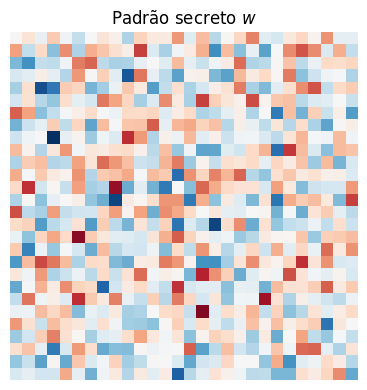

In [22]:
EPSILON        = 0.10
WM_FRACTION_SS = 0.20

# Gerado com OWNER_SEED (isolado do RNG global)
_owner_gen = torch.Generator().manual_seed(OWNER_SEED)
wm_pattern = torch.randn(1, 28, 28, generator=_owner_gen)
wm_pattern = wm_pattern - wm_pattern.mean()
wm_pattern = wm_pattern / wm_pattern.abs().max()

print(f"wm_pattern - média: {wm_pattern.mean().item():.2e}  max|w|: {wm_pattern.abs().max().item():.2f}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(wm_pattern.squeeze(), cmap="RdBu", vmin=-1, vmax=1)
ax.set_title("Padrão secreto $w$"); ax.axis("off")
plt.tight_layout(); plt.savefig(output_dir / "ss_pattern.png", dpi=120); plt.show()

Marcadas: 12,000 / 60,000


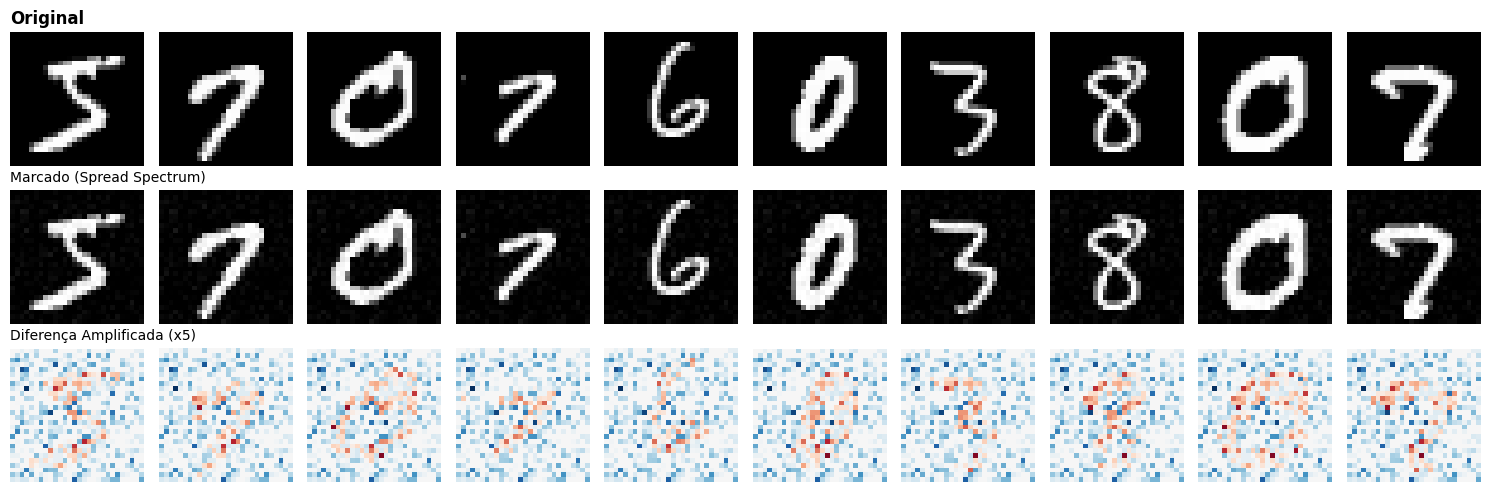

In [25]:
def apply_ss_watermark(img):
    # TODO
    imagem_mod = img.clone()
    imagem_ruido = imagem_mod + EPSILON * wm_pattern
    imagem_clamed = torch.clamp(imagem_ruido, 0.0, 1.0)
    return imagem_clamed
    


class SpreadSpectrumMNIST(Dataset):
    # TODO
    def __init__(self, base_dataset, fraction=WM_FRACTION_SS, seed=SEED):
        self.base_dataset = base_dataset
        self.fraction = fraction
        rng = np.random.default_rng(seed)
        indices_array = rng.choice(
            len(base_dataset), 
            size=int(len(base_dataset) * fraction), 
            replace=False
        )
        self.wm_indices = set(indices_array)

    def __len__(self):        
        return len(self.base_dataset)    
    
    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        if idx in self.wm_indices:
            img = apply_ss_watermark(img)
        return img, label
    


ss_ds = SpreadSpectrumMNIST(train_ds, fraction=WM_FRACTION_SS)
print(f"Marcadas: {len(ss_ds.wm_indices):,} / {len(ss_ds):,}")

# TODO: visualizar original vs marcado vs (marcado-original)*5
indices_ss = sorted(list(ss_ds.wm_indices))[:10]
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for i, idx in enumerate(indices_ss):    
    img_original, _ = train_ds[idx]
    img_marcada, _ = ss_ds[idx]
    img_diferenca = (img_marcada - img_original) * 5.0
    
    axes[0, i].imshow(img_original.squeeze(), cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")
        
    axes[1, i].imshow(img_marcada.squeeze(), cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_title("Marcado (Spread Spectrum)", loc="left", fontsize=10)
        
    axes[2, i].imshow(img_diferenca.squeeze(), cmap="RdBu", vmin=-EPSILON*5, vmax=EPSILON*5)
    axes[2, i].axis("off")
    if i == 0:
        axes[2, i].set_title("Diferença Amplificada (x5)", loc="left", fontsize=10)
plt.tight_layout()
plt.savefig(output_dir / "5.2_visualizacao_spread_spectrum.png", dpi=150)
plt.show()


In [24]:
ss_loader = DataLoader(ss_ds, 
                       batch_size=BATCH_SIZE, 
                       shuffle=True, 
                       num_workers=0, 
                       pin_memory=True)

# TODO: treine vae_ss e salve
vae_ss = train_vae(ss_loader, 
                   LATENT_DIM, 
                   epochs=30, 
                   label="spread_spectrum")
torch.save(vae_ss.state_dict(), output_dir / "vae_spread_spectrum.pt")
print("Modelo VAE treinado com dataset de marcação por Spread Spectrum e salvo com sucesso.")   


Treinando VAE SPREAD_SPECTRUM com LATENT_DIM=24 por 30 épocas...
Época   1/30 | Loss: 207.43 | Reconstrução: 202.95 | KL: 4.47
Época   2/30 | Loss: 153.49 | Reconstrução: 140.70 | KL: 12.79
Época   3/30 | Loss: 135.21 | Reconstrução: 119.51 | KL: 15.70
Época   4/30 | Loss: 127.25 | Reconstrução: 110.14 | KL: 17.11
Época   5/30 | Loss: 122.84 | Reconstrução: 104.87 | KL: 17.97
Época   6/30 | Loss: 119.97 | Reconstrução: 101.44 | KL: 18.53
Época   7/30 | Loss: 118.15 | Reconstrução: 99.27 | KL: 18.88
Época   8/30 | Loss: 116.71 | Reconstrução: 97.56 | KL: 19.15
Época   9/30 | Loss: 115.57 | Reconstrução: 96.23 | KL: 19.34
Época  10/30 | Loss: 114.60 | Reconstrução: 95.12 | KL: 19.48
Época  11/30 | Loss: 113.85 | Reconstrução: 94.25 | KL: 19.61
Época  12/30 | Loss: 113.17 | Reconstrução: 93.46 | KL: 19.71
Época  13/30 | Loss: 112.59 | Reconstrução: 92.78 | KL: 19.81
Época  14/30 | Loss: 112.06 | Reconstrução: 92.16 | KL: 19.90
Época  15/30 | Loss: 111.61 | Reconstrução: 91.60 | KL: 20.01


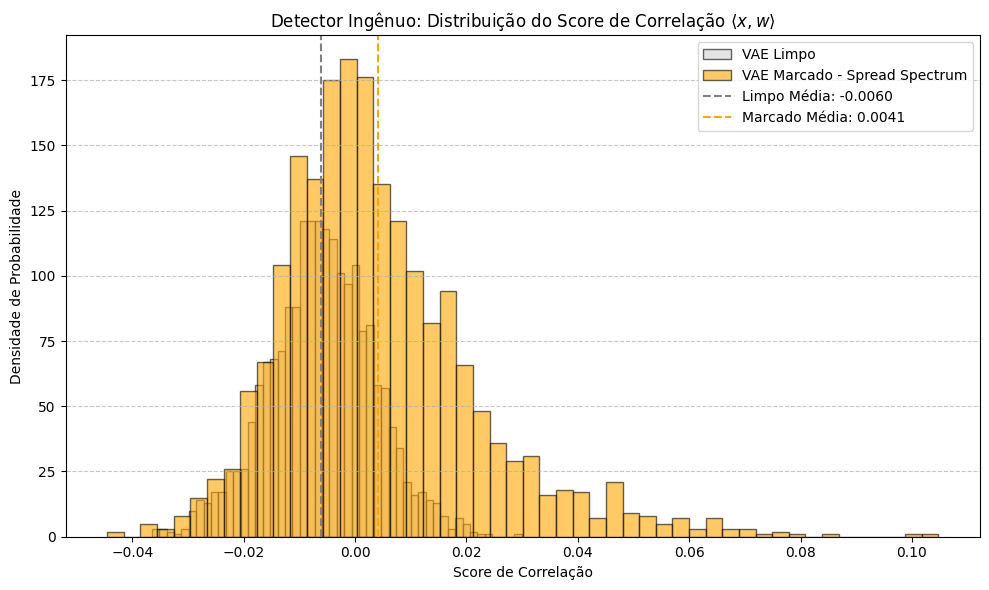

In [26]:
def corr_score(imgs, pattern):
    # TODO: produto interno por imagem
    return (imgs * pattern).sum(dim=(1, 2, 3)) / pattern.abs().sum()
    
N_AUDIT = 2000
model_5_2.eval()
vae_ss.eval()
# TODO: gerar amostras com o mesmo z, computar scores, plotar histogramas
with torch.no_grad():
    z_audit = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    x_gen_limpo = model_5_2.decoder(z_audit)
    x_gen_ss = vae_ss.decoder(z_audit)

pattern = wm_pattern.to(device)
scores_limpo = corr_score(x_gen_limpo, pattern).cpu().numpy()
scores_marcados = corr_score(x_gen_ss, pattern).cpu().numpy()

plt.figure(figsize=(10, 6))
plt.hist(scores_limpo, bins=50, alpha=0.6, label="VAE Limpo", color="lightgray", edgecolor="black")
plt.hist(scores_marcados, bins=50, alpha=0.6, label="VAE Marcado - Spread Spectrum", color="orange", edgecolor="black")

plt.axvline(scores_limpo.mean(), color="gray", linestyle="dashed", label=f"Limpo Média: {scores_limpo.mean():.4f}", linewidth=1.5)
plt.axvline(scores_marcados.mean(), color="orange", linestyle="dashed", label=f"Marcado Média: {scores_marcados.mean():.4f}", linewidth=1.5)    

plt.title("Detector Ingênuo: Distribuição do Score de Correlação $\\langle x, w \\rangle$")
plt.xlabel("Score de Correlação")
plt.ylabel("Densidade de Probabilidade")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(output_dir / "5.2_histogramas_scores.png", dpi=150)
plt.show()


In [27]:
# TODO: compute a imagem média do MNIST limpo (mu_mnist) e seu produto interno com wm_pattern
# Compare com a média do histograma do VAE limpo da seção anterior — devem ser parecidos.
# raise NotImplementedError


with torch.no_grad():
    todas_imagens = train_ds.data.float() / 255.0
    mu_mnist= todas_imagens.mean(dim=0).unsqueeze(0).to(device)
    wm_device = wm_pattern.to(device)
    offset_teorico = (mu_mnist * wm_device).sum().item()

print("Diagnótico do Detector Ingênuo:")    
print(f"Offset Teórico: {offset_teorico:.4f}")
print(f"Score Médio do VAE Limpo: {scores_limpo.mean():.4f}")
print(f"Score Médio do VAE Marcado: {scores_marcados.mean():.4f}")

diferenca = abs(offset_teorico - scores_marcados.mean())
print(f"Diferença Absoluta entre Offset Teórico e Score Médio do VAE Marcado: {diferenca:.4f}")

Diagnótico do Detector Ingênuo:
Offset Teórico: -1.0688
Score Médio do VAE Limpo: -0.0060
Score Médio do VAE Marcado: 0.0041
Diferença Absoluta entre Offset Teórico e Score Médio do VAE Marcado: 1.0729


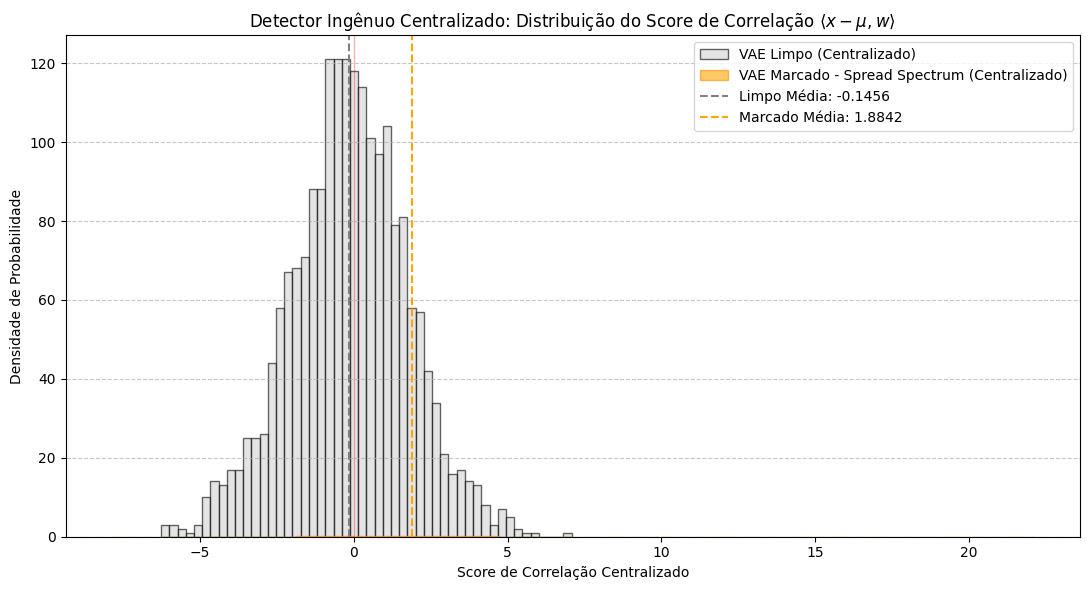

In [28]:
def corr_score_centered(imgs, pattern, mean_img):
    # TODO: <x - mean_img, pattern>
    imagem_centralizada = imgs - mean_img
    return (imagem_centralizada * pattern).sum(dim=(1, 2, 3))

model_5_2.eval()
vae_ss.eval()

with torch.no_grad():
    pattern = wm_pattern.to(device)
    acores_limpo_centered = corr_score_centered(x_gen_limpo, pattern, mu_mnist).cpu().numpy()
    acores_marcados_centered = corr_score_centered(x_gen_ss, pattern, mu_mnist).cpu().numpy()

plt.figure(figsize=(11, 6))
plt.hist(acores_limpo_centered, bins=50, alpha=0.6, label="VAE Limpo (Centralizado)", color="lightgray", edgecolor="black")
plt.hist(acores_marcados_centered, bins=50, alpha=0.6, label="VAE Marcado - Spread Spectrum (Centralizado)", color="orange", edgecolor="darkorange", density=True)

plt.axvline(acores_limpo_centered.mean(), color="gray", linestyle="dashed", label=f"Limpo Média: {acores_limpo_centered.mean():.4f}", linewidth=1.5)
plt.axvline(acores_marcados_centered.mean(), color="orange", linestyle="dashed", label=f"Marcado Média: {acores_marcados_centered.mean():.4f}", linewidth=1.5)  

plt.axvline(0.0, color="red", linestyle="-", alpha=0.3, linewidth=1.0)

plt.title("Detector Ingênuo Centralizado: Distribuição do Score de Correlação $\\langle x - \\mu, w \\rangle$")
plt.xlabel("Score de Correlação Centralizado")
plt.ylabel("Densidade de Probabilidade")
plt.legend(loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(output_dir / "5.2_histogramas_scores_centralizados.png", dpi=150)
plt.show()

# TODO: recomputar os scores e replotar o histograma centrado
# raise NotImplementedError

Media Limpo: -0.0620 | Media Marcado: 2.0314
Variância Limpo: 3.5758 | Variância Marcado: 14.0513
Erro Padrão Combinado: 0.0939
t-Estatístico: 22.2988


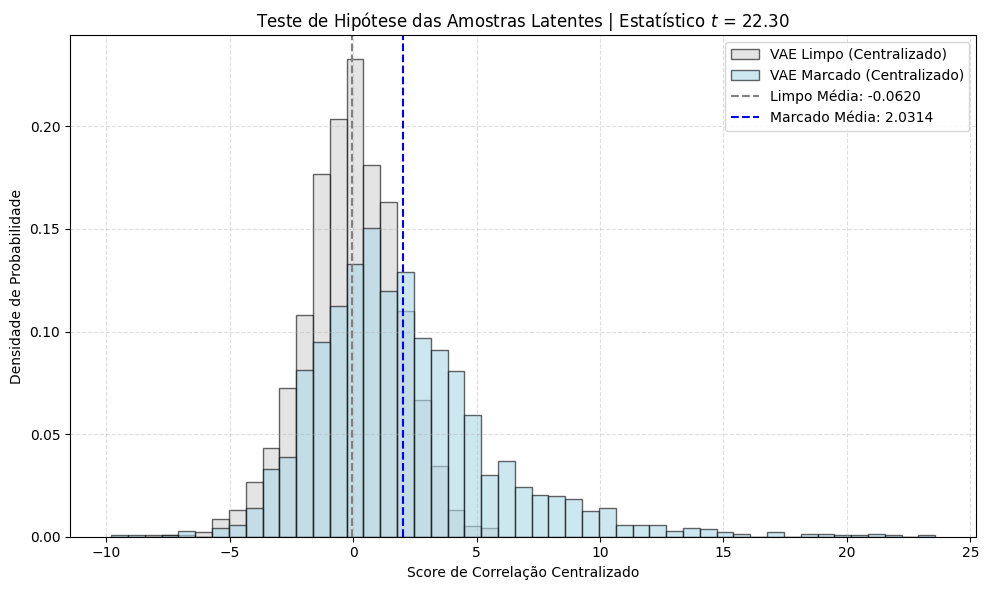

In [29]:
N_AUDIT = 2000

model_5_2.eval()
vae_ss.eval()

pattern = wm_pattern.to(device)
mu_mnist = mu_mnist.to(device)

with torch.no_grad():
    z_limpo = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    z_marcado = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    imagens_limpas = model_5_2.decoder(z_limpo)
    imagens_marcadas = vae_ss.decoder(z_marcado)
    scores_limpo_centered = corr_score_centered(imagens_limpas, pattern, mu_mnist)
    scores_marcado_centered = corr_score_centered(imagens_marcadas, pattern, mu_mnist)

sc_limpo = scores_limpo_centered.cpu().view(-1).numpy()
sc_marcado = scores_marcado_centered.cpu().view(-1).numpy()

mean_limpo = sc_limpo.mean()
mean_marcado = sc_marcado.mean()
var_limpo = np.var(sc_limpo, ddof=1)
var_marcado = np.var(sc_marcado, ddof=1)

erro_padrao_combinado = np.sqrt((var_limpo / N_AUDIT) + (var_marcado / N_AUDIT))
t_statistic = (mean_marcado - mean_limpo) / erro_padrao_combinado

print(f"Media Limpo: {mean_limpo:.4f} | Media Marcado: {mean_marcado:.4f}")
print(f"Variância Limpo: {var_limpo:.4f} | Variância Marcado: {var_marcado:.4f}")
print(f"Erro Padrão Combinado: {erro_padrao_combinado:.4f}")
print(f"t-Estatístico: {t_statistic:.4f}")

plt.figure(figsize=(10, 6))

min_val = min(sc_limpo.min(), sc_marcado.min()) - 0.5
max_val = max(sc_limpo.max(), sc_marcado.max()) + 0.5
bins = np.linspace(min_val, max_val, 50)
plt.hist(sc_limpo, 
         bins=bins, range=(min_val, max_val),
         alpha=0.6, label="VAE Limpo (Centralizado)", 
         color="lightgray", edgecolor="black", density=True)
plt.hist(sc_marcado,
         bins=bins, range=(min_val, max_val),
         alpha=0.6, label="VAE Marcado (Centralizado)", 
         color="lightblue", edgecolor="black", density=True)
plt.axvline(mean_limpo, color="gray", linestyle="dashed", label=f"Limpo Média: {mean_limpo:.4f}", linewidth=1.5)
plt.axvline(mean_marcado, color="blue", linestyle="dashed", label=f"Marcado Média: {mean_marcado:.4f}", linewidth=1.5)  

plt.title(f"Teste de Hipótese das Amostras Latentes | Estatístico $t$ = {t_statistic:.2f}")
plt.xlabel("Score de Correlação Centralizado")
plt.ylabel("Densidade de Probabilidade")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(output_dir / "5.2_teste_hipotese_hist.png", dpi=150)
plt.show()

# TODO: gerar N_AUDIT amostras INDEPENDENTES de cada modelo
# (dois torch.randn separados — não compartilhe z entre os modelos)
# Compute sc_clean e sc_ss usando corr_score_centered
# Compute o t-estatístico de duas amostras
#raise NotImplementedError

In [30]:
# TODO: escolha pelo menos 2 valores para cada parâmetro
EPSILON_VALUES  = [0.025, 0.05, 0.075, 0.10]   # ex: [0.05, 0.10]
FRACTION_VALUES = [0.05, 0.10, 0.15, 0.20]   # ex: [0.10, 0.20]
N_AUDIT         = 2000    # fixo
EPOCHS_ABLATION = 30     

# Definição do Dataset de Ablação Global
class AblationSpreadSpectrumMNIST(Dataset):
    def __init__(self, base_dataset, eps, fraction, seed=42):
        self.base_dataset = base_dataset
        self.eps = eps
        self.fraction = fraction
        
        # Sorteio estocástico rigoroso e isolado
        rng = np.random.default_rng(seed)
        num_samples = len(base_dataset)
        indices_array = rng.choice(num_samples, size=int(num_samples * fraction), replace=False)
        self.wm_indices = set(indices_array)
        
    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        if idx in self.wm_indices:
            # Multiplica o padrão wm_pattern pelo eps local desta instância
            img = torch.clamp(img.clone() + (self.eps * wm_pattern), 0.0, 1.0)
        return img, label


# Apontando o default da seed para 42 diretamente
def make_ss_dataset(eps, fraction, base_dataset=train_ds, seed=42):
    return AblationSpreadSpectrumMNIST(base_dataset, eps, fraction, seed=seed)

print("Passo Pré Ablação: Retreinando o VAE Limpo de Referência")
train_loader_ab = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

model_ab = train_vae(
    loader=train_loader_ab, 
    latent_dim=LATENT_DIM, 
    epochs=EPOCHS_ABLATION, 
    label="limpo_ablação"
)
# Retreina o VAE limpo com EPOCHS_ABLATION para comparação justa
# TODO: chamar train_vae com train_loader, LATENT_DIM, EPOCHS_ABLATION
# model_ab = ...
# raise NotImplementedError

Passo Pré Ablação: Retreinando o VAE Limpo de Referência
Treinando VAE LIMPO_ABLAÇÃO com LATENT_DIM=24 por 30 épocas...
Época   1/30 | Loss: 199.18 | Reconstrução: 194.31 | KL: 4.88
Época   2/30 | Loss: 145.71 | Reconstrução: 133.13 | KL: 12.59
Época   3/30 | Loss: 127.54 | Reconstrução: 112.70 | KL: 14.85
Época   4/30 | Loss: 119.31 | Reconstrução: 102.75 | KL: 16.56
Época   5/30 | Loss: 114.94 | Reconstrução: 97.51 | KL: 17.43
Época   6/30 | Loss: 112.00 | Reconstrução: 93.97 | KL: 18.02
Época   7/30 | Loss: 109.83 | Reconstrução: 91.37 | KL: 18.45
Época   8/30 | Loss: 108.37 | Reconstrução: 89.59 | KL: 18.78
Época   9/30 | Loss: 107.17 | Reconstrução: 88.16 | KL: 19.02
Época  10/30 | Loss: 106.23 | Reconstrução: 86.91 | KL: 19.32
Época  11/30 | Loss: 105.40 | Reconstrução: 85.92 | KL: 19.48
Época  12/30 | Loss: 104.59 | Reconstrução: 84.93 | KL: 19.66
Época  13/30 | Loss: 103.90 | Reconstrução: 84.06 | KL: 19.84
Época  14/30 | Loss: 103.32 | Reconstrução: 83.33 | KL: 19.99
Época  15

In [31]:
# TODO: implementar a varredura
# Para cada (eps, frac) em EPSILON_VALUES × FRACTION_VALUES:
#   1. Crie o dataset com make_ss_dataset(eps, frac)
#   2. Treine um VAE com EPOCHS_ABLATION épocas
#   3. Gere N_AUDIT amostras INDEPENDENTES de model_ab e do VAE marcado
#   4. Compute o t-estatístico de duas amostras e o sinal médio
#   5. Guarde em results como dict {"eps": ..., "frac": ..., "signal": ..., "t": ...}

#VARREDURA DE ABLAÇÃO COM ESTRUTURA DE DICIONÁRIOS
mu_mnist_device = mu_mnist.to(device)
results = []

print("\nExecutando a Grade de Ablação")
for eps in EPSILON_VALUES:
    for frac in FRACTION_VALUES:
        print(f"\nAvaliando: Epsilon = {eps:.2f} | Fração = {frac:.2f}")
        
        # Criando o dataset com make_ss_dataset(eps, frac)
        ablation_ds = make_ss_dataset(eps, frac, train_ds)
        ablation_loader = DataLoader(ablation_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
        
        # VAE com EPOCHS_ABLATION épocas
        vae_local = train_vae(
            loader=ablation_loader,
            latent_dim=LATENT_DIM,
            epochs=EPOCHS_ABLATION,
            label=f"ab_eps{eps}_frac{frac}"
        )
        
        # Gerando N_AUDIT amostras INDEPENDENTES de model_ab e do VAE marcado
        model_ab.eval()
        vae_local.eval()
        with torch.no_grad():
            z_clean = torch.randn(N_AUDIT, LATENT_DIM).to(device)
            z_ss = torch.randn(N_AUDIT, LATENT_DIM).to(device)
            
            sc_clean = corr_score_centered(model_ab.decoder(z_clean), wm_pattern.to(device), mu_mnist_device).cpu().view(-1).numpy()
            sc_ss = corr_score_centered(vae_local.decoder(z_ss), wm_pattern.to(device), mu_mnist_device).cpu().view(-1).numpy()
            
        # Computando o t-estatístico de duas amostras e o sinal médio
        v_clean, v_ss = np.var(sc_clean, ddof=1), np.var(sc_ss, ddof=1)
        mean_clean = np.mean(sc_clean)
        mean_ss = np.mean(sc_ss)
        
        t_stat = (mean_ss - mean_clean) / np.sqrt((v_clean + v_ss) / N_AUDIT)
        
        # Guardando em results como dict {"eps": ..., "frac": ..., "signal": ..., "t": ...}
        results.append({
            "eps": eps, 
            "frac": frac, 
            "signal": mean_ss, 
            "t": t_stat
        })
        
        print(f"-> Resultados guardados: t={t_stat:.4f} | signal={mean_ss:.4f}")
        
        # Limpeza física de memória GPU
        del vae_local, ablation_ds, ablation_loader
        torch.cuda.empty_cache()

print("\nVarredura concluída e salva na lista 'results'.")


Executando a Grade de Ablação

Avaliando: Epsilon = 0.03 | Fração = 0.05
Treinando VAE AB_EPS0.025_FRAC0.05 com LATENT_DIM=24 por 30 épocas...
Época   1/30 | Loss: 198.60 | Reconstrução: 193.84 | KL: 4.75
Época   2/30 | Loss: 142.98 | Reconstrução: 130.16 | KL: 12.82
Época   3/30 | Loss: 126.79 | Reconstrução: 111.86 | KL: 14.93
Época   4/30 | Loss: 119.56 | Reconstrução: 103.37 | KL: 16.19
Época   5/30 | Loss: 115.53 | Reconstrução: 98.44 | KL: 17.09
Época   6/30 | Loss: 112.91 | Reconstrução: 95.31 | KL: 17.60
Época   7/30 | Loss: 111.07 | Reconstrução: 93.11 | KL: 17.96
Época   8/30 | Loss: 109.52 | Reconstrução: 91.30 | KL: 18.23
Época   9/30 | Loss: 108.33 | Reconstrução: 89.95 | KL: 18.39
Época  10/30 | Loss: 107.39 | Reconstrução: 88.83 | KL: 18.55
Época  11/30 | Loss: 106.63 | Reconstrução: 87.94 | KL: 18.69
Época  12/30 | Loss: 105.93 | Reconstrução: 87.12 | KL: 18.81
Época  13/30 | Loss: 105.41 | Reconstrução: 86.49 | KL: 18.92
Época  14/30 | Loss: 104.82 | Reconstrução: 85.

In [34]:
import pandas as pd
import seaborn as sns

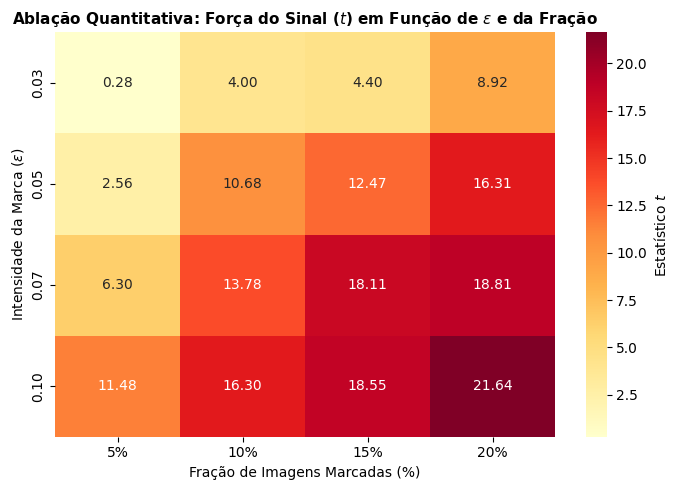

In [36]:
# Converte a lista de dicionários em um DataFrame para facilitar a extração
df_results = pd.DataFrame(results)

# Cria a matriz pivotada (linhas = epsilons, colunas = fractions, valores = t)
t_matrix_df = df_results.pivot(index="eps", columns="frac", values="t")

# GERAÇÃO DO HEATMAP SEABORN 
plt.figure(figsize=(7, 5))
sns.heatmap(
    t_matrix_df, 
    annot=True, 
    fmt=".2f", 
    xticklabels=[f"{f*100:.0f}%" for f in t_matrix_df.columns],
    yticklabels=[f"{e:.2f}" for e in t_matrix_df.index],
    cmap="YlOrRd", 
    cbar_kws={'label': 'Estatístico $t$'}
)
plt.title("Ablação Quantitativa: Força do Sinal ($t$) em Função de $\\varepsilon$ e da Fração", fontsize=11, fontweight="bold")
plt.xlabel("Fração de Imagens Marcadas (%)")
plt.ylabel("Intensidade da Marca ($\\varepsilon$)")
plt.tight_layout()
plt.savefig(output_dir / "5.2_heatmap_ablacao.png", dpi=150)
plt.show()

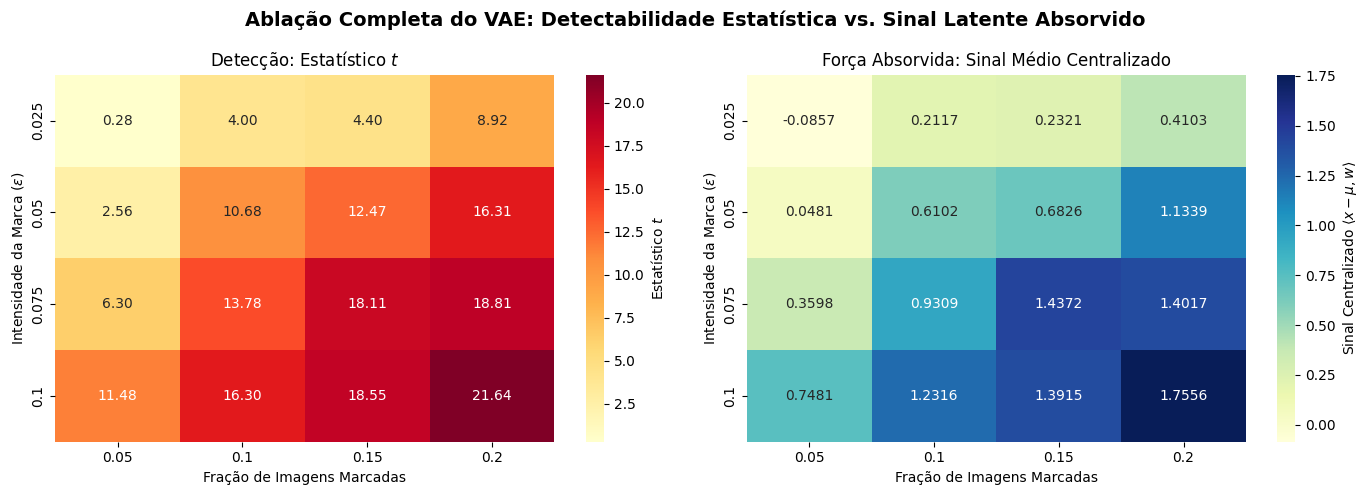


Resumo dos Resultados Finais:


signal                                        t             \
frac       0.05      0.10      0.15      0.20       0.05       0.10   
eps                                                                   
0.025 -0.085720  0.211693  0.232129  0.410306   0.277959   4.004516   
0.050  0.048078  0.610219  0.682603  1.133924   2.556072  10.683808   
0.075  0.359808  0.930857  1.437210  1.401662   6.298456  13.783469   
0.100  0.748060  1.231581  1.391503  1.755647  11.478979  16.302805   

                             
frac        0.15       0.20  
eps                          
0.025   4.396067   8.922762  
0.050  12.472178  16.311335  
0.075  18.110680  18.808064  
0.100  18.552616  21.639608

In [37]:
# TODO: heatmap signal_grid, heatmap t_grid
# raise NotImplementedError

# Transformação de Dados: Converte a lista de dicionários da varredura em um DataFrame
df_results = pd.DataFrame(results)

# Pivotamento: Cria duas matrizes estruturadas (linhas=eps, colunas=frac)
t_matrix_df = df_results.pivot(index="eps", columns="frac", values="t")
signal_matrix_df = df_results.pivot(index="eps", columns="frac", values="signal")

# Configuração: Figura ampla com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HEATMAP 1: O ESTATÍSTICO t 
sns.heatmap(
    t_matrix_df, 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrRd", # Cores quentes para denotar o "alerta" estatístico
    ax=axes[0],
    cbar_kws={'label': 'Estatístico $t$'}
)
axes[0].set_title("Detecção: Estatístico $t$", fontsize=12)
axes[0].set_xlabel("Fração de Imagens Marcadas")
axes[0].set_ylabel("Intensidade da Marca ($\\varepsilon$)")

# HEATMAP 2: O SINAL MÉDIO
sns.heatmap(
    signal_matrix_df, 
    annot=True, 
    fmt=".4f", 
    cmap="YlGnBu", # Cores frias para separar visualmente do gráfico anterior
    ax=axes[1],
    cbar_kws={'label': 'Sinal Centralizado $\\langle x - \\mu, w \\rangle$'}
)
axes[1].set_title("Força Absorvida: Sinal Médio Centralizado", fontsize=12)
axes[1].set_xlabel("Fração de Imagens Marcadas")
axes[1].set_ylabel("Intensidade da Marca ($\\varepsilon$)")

# Ajuste global de espaçamento e salvamento do artefato
plt.suptitle("Ablação Completa do VAE: Detectabilidade Estatística vs. Sinal Latente Absorvido", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(output_dir / "4.2_heatmaps_ablation.png", dpi=150)
plt.show()

print("\nResumo dos Resultados Finais:")
display(df_results.pivot(index="eps", columns="frac", values=["signal", "t"]))

*Escreva sua resposta aqui (tabela + análise).*

<span style="color:blue"> Um VAE com maior dimensão latente é forçado pela Loss a atuar como um memorizador mais fiel da entrada exata. Ele reproduz o ruído spread-spectrum nas imagens geradas com mais fidelidade geométrica, o que infla a correlação e faz o estatístico $t$ aumentar, tornando a auditoria da marca d'água muito mais assertiva </span>

---

## Critérios de avaliação

| Parte | Peso | Critério |
|-------|------|----------|
| 0–1   | 20%  | VAE correto e visualizações. Q1. |
| 2     | 20%  | Marca visível e auditoria. Q2. |
| 3     | 30%  | Spread-spectrum, diagnóstico do offset, detector centralizado, teste. Q3. |
| 4     | 30%  | Ablação completa e heatmaps. Q4 com análise quantitativa. |
| 5 (bônus) | +10% | Uma das duas extensões opcionais (5.1 ou 5.2). |